# Whole-pipeline threshold evaluation (per-stage)

This notebook evaluates the **entire prediction cascade** (`Pipeline.run` in
`phishing_engine/core/pipeline.py`) end-to-end and characterizes how its decision
thresholds trade detection quality against latency.

stages run in order `url -> content -> domain`; a stage with `P(phish) >= its threshold`
**early-exits** with that stage's own model verdict; otherwise the URL escalates, and if no
stage exits the cascade **aggregates** every stage's probability (`mean`/`max`/`median` per
`decision.fallback_aggregation`) against the fixed `FALLBACK_DECISION_BOUNDARY` (0.5).

**Per-stage thresholds.** Each stage's early-exit bar is its own `StageConfig.threshold`,
falling back to the pipeline-wide `decision.threshold`. This notebook (1) sweeps a single
**shared** threshold as the baseline, (2) evaluates the **shipped per-stage config**, and
(3) **searches** for a better per-stage combination -- all on the held-out TEST split.

**Method.**
1. Extract all three stages' features for every labeled URL using the engine's own
   extractors (train/predict parity), keyed per-URL.
2. **Domain-grouped split** keyed on **registered domain (eTLD+1)** so no host crosses
   splits -- host-shared `domain` features can no longer leak train->test.
3. **80/20 train / test.** For each stage, train the model zoo on **train** and keep the best
   by `SELECTION_METRIC` on **test** (no separate validation split).
4. Score per-URL stage probabilities and **replay the real cascade** by reusing
   `Pipeline._build_result` (so the verdict can't drift from production), now honoring
   per-stage thresholds exactly like runtime.
5. Baseline shared-threshold sweep, then the shipped per-stage config, then a per-stage
   sensitivity analysis + (url x content) grid search.
6. Show the **latency vs F1 trade-off**, placing the per-stage operating points in that space.

**Prerequisites:** MongoDB running with collected, labeled data; run with the project's
`.venv` kernel; working directory = repo root (where `config/pipeline.json` lives).


## Setup

In [1]:
import os, sys, time, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import tldextract                       # registered-domain (eTLD+1) grouping for the split

# Make the project importable when the kernel's cwd is the repo root.
sys.path.insert(0, os.path.abspath("."))

import phishing_engine.stages  # noqa: F401  (registers url/domain/content stages)
from phishing_engine.core.config import load_config
from phishing_engine.core.registry import get_stage
from phishing_engine.core.pipeline import Pipeline, PipelineContext, FALLBACK_DECISION_BOUNDARY
from phishing_engine.storage.mongo import MongoStore

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

# Model zoo (mirrors model_evaluation.ipynb). sklearn's Pipeline is aliased to SkPipeline
# so it does not shadow phishing_engine's cascade Pipeline imported above.
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
print("imports ok; FALLBACK_DECISION_BOUNDARY =", FALLBACK_DECISION_BOUNDARY)

imports ok; FALLBACK_DECISION_BOUNDARY = 0.5


### Parameters

In [2]:
CONFIG_PATH = "config/pipeline.json"
# Cap on labeled docs (0 = all). Override with PHISH_EVAL_LIMIT for a quick smoke run.
LIMIT       = int(os.environ.get("PHISH_EVAL_LIMIT", "0"))
RS          = 42          # shared random_state for the split + every model

# Per-stage model selection: train the zoo on TRAIN, keep the best by SELECTION_METRIC on TEST.
# (No separate validation split -- selecting the best-of-N on the test set gives the reported
# metrics a mild optimistic bias, accepted here for simplicity.) INCLUDE_SLOW_MODELS adds SVM.
SELECTION_METRIC    = "f1"   # column the per-stage zoo is ranked by (on test)
INCLUDE_SLOW_MODELS = False

# Domain-GROUPED split keyed on registered domain (eTLD+1): no domain crosses splits, so
# host-shared domain features can't leak train->test. 80/20 train/test via
# StratifiedGroupKFold(n_splits=5): 1 fold test / 4 folds train.
TRAIN_FRAC, TEST_FRAC = 0.8, 0.2

# Grid swept over the cascade's early-exit threshold. We report the whole curve; no single
# threshold is prescribed (see the sweep + latency sections).
THRESHOLDS = np.round(np.linspace(0.0, 1.0, 101), 4)

# Joint per-URL feature cache (extraction over thousands of docs is the slow part).
FEATURE_CACHE_DIR = "feature_cache"
USE_FEATURE_CACHE = True
FORCE_RECALC      = False
print(f"LIMIT={LIMIT}  selection_metric={SELECTION_METRIC}  include_slow={INCLUDE_SLOW_MODELS}")
print(f"split(grouped, eTLD+1)={TRAIN_FRAC}/{TEST_FRAC}")

LIMIT=0  selection_metric=f1  include_slow=False
split(grouped, eTLD+1)=0.8/0.2


### Connect to MongoDB and read the decision policy

The threshold/labels/aggregation come straight from the config's `pipeline.decision`
block, so the sweep is measured against the exact policy the engine ships with.

In [3]:
config   = load_config(CONFIG_PATH)
mongo    = config.pipeline.mongo
DECISION = config.pipeline.decision
STAGE_CONFIGS = {s.id: s for s in config.pipeline.stages}
POSITIVE = DECISION.positive_label   # "phish"
NEGATIVE = DECISION.negative_label   # "benign"

store = MongoStore(mongo.uri, mongo.database, mongo.collection, mongo.domain_collection)
print(f"db={mongo.database!r} urls={mongo.collection!r} domains={mongo.domain_collection!r}")
print(f"decision: margin(default)={DECISION.margin} positive={POSITIVE!r} "
      f"negative={NEGATIVE!r} fallback_aggregation={DECISION.fallback_aggregation!r}")
print("per-stage deferral margins:",
      {s.id: s.margin for s in config.pipeline.stages})
print("labeled docs with a domain record:", store.count_labeled(require="domain_record", limit=LIMIT))


db='phishing_engine' urls='url_documents' domains='domain_records'
decision: margin(default)=0.4 positive='phish' negative='benign' fallback_aggregation='mean'
per-stage deferral margins: {'url': 0.49, 'content': 0.28, 'domain': 0.1}


labeled docs with a domain record: 10625


## Feature extraction and train/test split

### Joint per-URL feature extraction

One pass over `iter_labeled(require="domain_record")` (which `$lookup`-joins the domain
record and still carries `raw.content` when present). For each URL we run the **same**
extractors the training/prediction pipelines use and key everything by URL `_id`:

- **url** features from the URL string (always available),
- **domain** features from `raw.domain_record` (identical for every URL of a host),
- **content** features from `raw.content` when the page was collected.

`domain_ok` / `content_ok` record whether a stage produced features; a stage with no
features contributes no probability later (mirroring the cascade's "escalate" path). The
aligned matrices are cached to `feature_cache/` so re-runs skip the slow extraction.

In [4]:
URL_COLS     = STAGE_CONFIGS["url"].feature_columns
CONTENT_COLS = STAGE_CONFIGS["content"].feature_columns   # domain stage has no fixed columns

def _align(df, cols):
    '''Coerce to numeric (bools->0/1); if cols given, add missing + order to them, drop extras.

    Mirrors the coercion in core/training.py so the offline features match training exactly.
    '''
    df = df.replace({True: 1, False: 0})
    if cols:
        for c in cols:
            if c not in df.columns:
                df[c] = 0
        df = df[cols]
    return df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

def _cache_paths(limit):
    suf = f"_lim{limit}" if limit else ""
    base = os.path.join(FEATURE_CACHE_DIR, f"pipeline_joint{suf}")
    return {k: f"{base}_{k}.csv" for k in ("meta", "url", "domain", "content")}

def build_joint_dataset(limit=LIMIT):
    paths = _cache_paths(limit)
    if USE_FEATURE_CACHE and not FORCE_RECALC and all(os.path.exists(p) for p in paths.values()):
        meta = pd.read_csv(paths["meta"])
        url_df, dom_df, con_df = (pd.read_csv(paths[k]) for k in ("url", "domain", "content"))
        print(f"[cache] loaded joint dataset: {len(meta)} URLs  ({FEATURE_CACHE_DIR}/)")
        return meta, url_df, dom_df, con_df

    url_stage = get_stage("url")(STAGE_CONFIGS["url"], None)
    dom_stage = get_stage("domain")(STAGE_CONFIGS["domain"], None)
    con_stage = get_stage("content")(STAGE_CONFIGS["content"], None)

    ids, refs, labels, has_content, dom_ok, con_ok = [], [], [], [], [], []
    url_rows, dom_rows, con_rows = [], [], []
    failed = 0
    t0 = time.perf_counter()
    total = store.count_labeled(require="domain_record", limit=limit)
    it = tqdm(store.iter_labeled(require="domain_record", limit=limit),
              total=total, desc="extracting features", unit="doc")
    for doc in it:
        label = doc.get("label")
        if label not in ("phish", "benign"):
            continue
        ctx = PipelineContext(url=doc.get("url", ""), normalized_url=doc["_id"],
                              domain=doc.get("domain", ""), label=label)
        raw = doc.get("raw") or {}
        try:
            u = url_stage.extract_features(ctx, {})
        except Exception:
            failed += 1
            continue
        try:
            d = dom_stage.extract_features(ctx, dom_stage.build_train_artifacts(doc))
        except Exception:
            d = {}
        if raw.get("content") is not None:
            try:
                c = con_stage.extract_features(ctx, con_stage.build_train_artifacts(doc))
            except Exception:
                c = {}
            hc = True
        else:
            c, hc = {}, False

        ids.append(doc["_id"]); refs.append(raw.get("domain_record_ref")); labels.append(label)
        has_content.append(hc); dom_ok.append(bool(d)); con_ok.append(hc and bool(c))
        url_rows.append(u); dom_rows.append(d); con_rows.append(c)

    print(f"extracted {len(ids)} URLs in {time.perf_counter() - t0:.0f}s "
          f"({failed} url-extraction failures skipped)")

    meta = pd.DataFrame({"_id": ids, "domain_ref": refs, "_label": labels,
                         "has_content": has_content, "domain_ok": dom_ok, "content_ok": con_ok})
    url_df = _align(pd.DataFrame(url_rows), URL_COLS)
    dom_df = _align(pd.DataFrame(dom_rows), None)          # keep extractor-produced columns
    con_df = _align(pd.DataFrame(con_rows), CONTENT_COLS)

    if USE_FEATURE_CACHE:
        os.makedirs(FEATURE_CACHE_DIR, exist_ok=True)
        meta.to_csv(paths["meta"], index=False)
        url_df.to_csv(paths["url"], index=False)
        dom_df.to_csv(paths["domain"], index=False)
        con_df.to_csv(paths["content"], index=False)
        print(f"[cache] saved joint dataset -> {FEATURE_CACHE_DIR}/")
    return meta, url_df, dom_df, con_df

meta, url_df, dom_df, con_df = build_joint_dataset()

# Positional alignment across every frame (index == row position).
meta   = meta.reset_index(drop=True)
url_df = url_df.reset_index(drop=True)
dom_df = dom_df.reset_index(drop=True)
con_df = con_df.reset_index(drop=True)
y = (meta["_label"].to_numpy() == POSITIVE).astype(int)

print("shapes:", {"meta": meta.shape, "url": url_df.shape,
                  "domain": dom_df.shape, "content": con_df.shape})
print(f"phish={int(y.sum())} benign={int((y == 0).sum())} | "
      f"with content={int(meta['has_content'].sum())} | "
      f"domain_ok={int(meta['domain_ok'].sum())} content_ok={int(meta['content_ok'].sum())}")

[cache] loaded joint dataset: 10306 URLs  (feature_cache/)
shapes: {'meta': (10306, 6), 'url': (10306, 39), 'domain': (10306, 136), 'content': (10306, 111)}
phish=4823 benign=5483 | with content=9618 | domain_ok=10306 content_ok=9618


### Domain-grouped train / test split

The split is keyed on the **registered domain (eTLD+1)** so **no domain crosses splits** --
host-shared `domain` features (identical for every URL of a host) therefore can't leak from
train into test, which a per-URL random split allowed (it put ~46% of test URLs on a
train-seen domain). **80/20** via `StratifiedGroupKFold(5)` (4 folds train / 1 fold test); a
leakage guard asserts the two domain sets are disjoint. Each stage's best model is picked on
the test split (no separate validation set).

In [5]:
# group key = registered domain (eTLD+1); offline (bundled suffix snapshot, no network).
_tld = tldextract.TLDExtract(suffix_list_urls=())

def _registered_domain(domain_ref, _id):
    host = domain_ref.split("|", 1)[0] if isinstance(domain_ref, str) and domain_ref else ""
    if not host:
        return str(_id)                       # fall back to the URL id if no host
    return _tld(host).registered_domain or host

groups = np.array([_registered_domain(r, i)
                   for r, i in zip(meta["domain_ref"], meta["_id"])])
print(f"registered-domain groups: {len(set(groups))}  (from {meta['_id'].nunique()} URLs)")

# grouped, stratified 80/20 split via 5 folds -> 1 test / 4 train.
sgkf  = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RS)
folds = [te for _, te in sgkf.split(np.arange(len(meta)), y, groups)]
test_idx  = folds[0]
train_idx = np.concatenate(folds[1:])

for name, idx in [("train", train_idx), ("test", test_idx)]:
    yy = y[idx]
    assert set(np.unique(yy)) == {0, 1}, f"{name} split is single-class; adjust seed/LIMIT"
    print(f"{name:5}: {len(idx):5} URLs  ({len(set(groups[idx])):4} domains)  "
          f"phish={int(yy.sum())} benign={int((yy == 0).sum())}")

# leakage guard: registered domains must be disjoint across train/test.
_g = {n: set(groups[i]) for n, i in [("tr", train_idx), ("te", test_idx)]}
assert not (_g["tr"] & _g["te"]), "domain leak across splits!"
print("leakage guard: 0 shared domains across train/test  OK")

registered-domain groups: 4258  (from 10306 URLs)


train:  8188 URLs  (3757 domains)  phish=3801 benign=4387
test :  2118 URLs  ( 501 domains)  phish=1022 benign=1096
leakage guard: 0 shared domains across train/test  OK


## Per-stage model selection

Each stage trains every algorithm (Logistic Regression, Decision Tree, Random Forest, Extra
Trees, Gradient Boosting, KNN, XGBoost, LightGBM; SVM optional) on the **train** split and
keeps the **best by `SELECTION_METRIC` on the TEST split** to drive the cascade. Each stage is
fit on the unit it predicts on:

- **url** / **content**: one row per URL (content only on URLs whose page was collected).
- **domain**: deduplicated to one row per `domain_ref`, labeled `phish` if *any* URL of
  that domain is phish (matching `collect_training_data` in `core/training.py`).

Labels are encoded `1=phish / 0=benign`; `phish_proba` reads the phish column back via
`model.classes_`. (With no separate validation split, selection and reporting share the test
set, so the headline numbers carry a mild optimistic bias.)

In [6]:
def make_models():
    '''Candidate models per stage -- same zoo as model_evaluation.ipynb.'''
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    models = {
        "Logistic Regression": SkPipeline([("scaler", StandardScaler()),
                                           ("clf", LogisticRegression(max_iter=1000, random_state=RS))]),
        "Decision Tree":     DecisionTreeClassifier(random_state=RS),
        "Random Forest":     RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RS),
        "Extra Trees":       ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=RS),
        "Gradient Boosting": GradientBoostingClassifier(random_state=RS),
        "KNN":               SkPipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        "XGBoost":           XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                                           subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                                           tree_method="hist", n_jobs=-1, random_state=RS),
        "LightGBM":          LGBMClassifier(n_estimators=400, learning_rate=0.05, n_jobs=-1,
                                            random_state=RS, verbose=-1),
    }
    if INCLUDE_SLOW_MODELS:
        models["SVM (RBF)"] = SkPipeline([("scaler", StandardScaler()),
                                          ("clf", SVC(kernel="rbf", probability=True, random_state=RS))])
    return models

def phish_proba(model, X):
    '''P(phish) column, located via model.classes_ (labels are 1=phish / 0=benign).'''
    idx = list(model.classes_).index(1)
    return model.predict_proba(X)[:, idx]

def _dedup_domain(idx):
    '''Rows + labels for one row per domain_ref (features identical within a host;
    phish if any URL of the ref is phish) -- matches collect_training_data.'''
    rows, labels = [], []
    for ref, sub in meta.iloc[idx].groupby("domain_ref"):
        ok = sub.index[sub["domain_ok"].to_numpy()]
        if len(ok) == 0:
            continue                                   # this domain produced no features
        rows.append(int(ok[0]))                        # features identical within a domain
        labels.append(1 if (sub["_label"] == POSITIVE).any() else 0)
    return rows, np.array(labels)

def stage_matrices(stage):
    '''(X_train, y_train, X_test, y_test) for one stage, on its prediction unit.'''
    if stage == "url":
        return url_df.iloc[train_idx], y[train_idx], url_df.iloc[test_idx], y[test_idx]
    if stage == "content":
        sel = lambda I: [int(i) for i in I if meta.at[int(i), "content_ok"]]
        tr, te = sel(train_idx), sel(test_idx)
        return con_df.loc[tr], y[tr], con_df.loc[te], y[te]
    if stage == "domain":
        tr, ytr = _dedup_domain(train_idx)
        te, yte = _dedup_domain(test_idx)
        return dom_df.loc[tr], ytr, dom_df.loc[te], yte
    raise ValueError(stage)

def _score(y_true, proba):
    '''Threshold-independent (PR-AUC, ROC-AUC) + 0.5-boundary metrics for one model.'''
    preds = (proba >= 0.5).astype(int)
    multi = len(np.unique(y_true)) > 1
    return {"pr_auc":    average_precision_score(y_true, proba) if multi else float("nan"),
            "roc_auc":   roc_auc_score(y_true, proba) if multi else float("nan"),
            "f1":        f1_score(y_true, preds, zero_division=0),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall":    recall_score(y_true, preds, zero_division=0),
            "accuracy":  accuracy_score(y_true, preds)}

def select_best(stage):
    '''Fit every zoo model on train; rank by SELECTION_METRIC on the TEST split.'''
    Xtr, ytr, Xte, yte = stage_matrices(stage)
    assert set(np.unique(ytr)) == {0, 1}, f"{stage} train split single-class; adjust seed/LIMIT"
    rows, fitted = [], {}
    for name, model in make_models().items():
        t0 = time.perf_counter()
        try:
            model.fit(Xtr, ytr)
        except Exception as e:
            print(f"  [skip] {stage}/{name}: {e}")
            continue
        rows.append({"model": name, **_score(yte, phish_proba(model, Xte)),
                     "fit_sec": time.perf_counter() - t0})
        fitted[name] = model
    table = pd.DataFrame(rows).sort_values(SELECTION_METRIC, ascending=False).reset_index(drop=True)
    best_name = table.iloc[0]["model"]
    counts = (len(ytr), int(np.asarray(ytr).sum()), len(yte), int(np.asarray(yte).sum()))
    return table, fitted, best_name, counts

STAGES = ["url", "domain", "content"]
stage_tables, fitted_models, selected, stage_counts = {}, {}, {}, {}
for stage in STAGES:
    table, fitted, best_name, counts = select_best(stage)
    stage_tables[stage]  = table
    fitted_models[stage] = fitted
    selected[stage]      = best_name
    stage_counts[stage]  = counts
    top = table.iloc[0]
    print(f"{stage:8} best by {SELECTION_METRIC}: {best_name:20} "
          f"(TEST PR-AUC={top['pr_auc']:.4f} ROC-AUC={top['roc_auc']:.4f} F1@.5={top['f1']:.4f})  "
          f"train={counts[0]}(phish={counts[1]}) / test={counts[2]}(phish={counts[3]})")

# the cascade uses each stage's winning model
url_model = fitted_models["url"][selected["url"]]
dom_model = fitted_models["domain"][selected["domain"]]
con_model = fitted_models["content"][selected["content"]]
MODEL_DESC = " | ".join(f"{s}:{selected[s]}" for s in STAGES)
print("\nselected models ->", MODEL_DESC)

url      best by f1: LightGBM             (TEST PR-AUC=0.9998 ROC-AUC=0.9997 F1@.5=0.9793)  train=8188(phish=3801) / test=2118(phish=1022)


domain   best by f1: XGBoost              (TEST PR-AUC=0.9987 ROC-AUC=0.9986 F1@.5=0.9893)  train=5039(phish=2990) / test=1368(phish=835)


content  best by f1: Extra Trees          (TEST PR-AUC=0.9784 ROC-AUC=0.9876 F1@.5=0.9661)  train=7544(phish=3294) / test=2074(phish=1022)

selected models -> url:LightGBM | domain:XGBoost | content:Extra Trees


### Per-stage model comparison & selected best

The full ranking of every candidate per stage (sorted by the selection metric), then the
best-per-stage summary and a side-by-side bar chart of the chosen models' headline metrics.
All numbers here are on the **test** split.


===== url  (best by f1: LightGBM) =====
              model  pr_auc  roc_auc     f1  precision  recall  accuracy  fit_sec
           LightGBM  0.9998   0.9997 0.9793     0.9622  0.9971    0.9797   0.4039
        Extra Trees  0.9778   0.9952 0.9789     0.9587  1.0000    0.9792   0.7463
            XGBoost  0.9997   0.9997 0.9784     0.9587  0.9990    0.9788   0.3610
      Random Forest  0.9862   0.9959 0.9779     0.9586  0.9980    0.9783   0.9162
                KNN  0.9874   0.9940 0.9729     0.9472  1.0000    0.9731   0.0688
  Gradient Boosting  0.9996   0.9996 0.9714     0.9470  0.9971    0.9717   1.1279
Logistic Regression  0.9988   0.9989 0.9682     0.9393  0.9990    0.9684   0.0596
      Decision Tree  0.9420   0.9702 0.9663     0.9391  0.9951    0.9665   0.0529

===== domain  (best by f1: XGBoost) =====
              model  pr_auc  roc_auc     f1  precision  recall  accuracy  fit_sec
            XGBoost  0.9987   0.9986 0.9893     0.9789  1.0000    0.9868   0.7684
      Random F

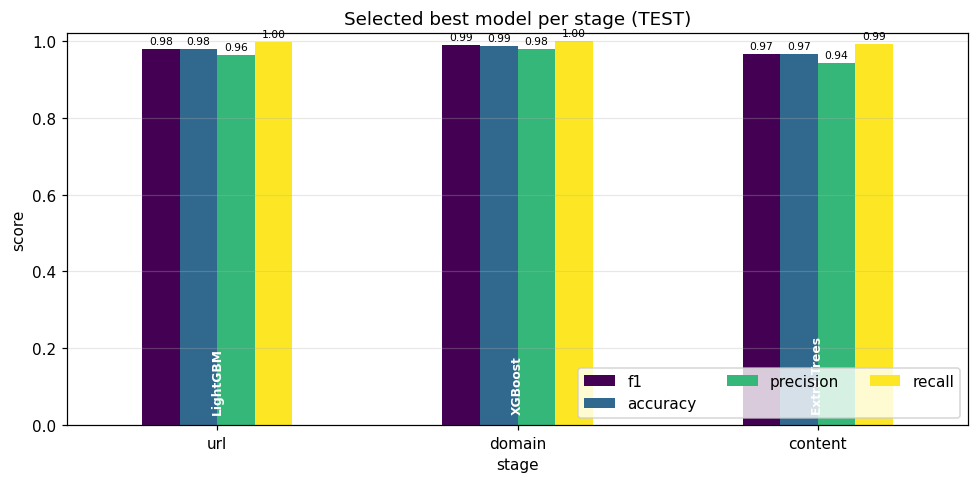

,best_model,pr_auc,roc_auc,precision,recall,f1,accuracy
stage,,,,,,,
url,LightGBM,0.9998,0.9997,0.9622,0.9971,0.9793,0.9797
domain,XGBoost,0.9987,0.9986,0.9789,1.0000,0.9893,0.9868
content,Extra Trees,0.9784,0.9876,0.9423,0.9912,0.9661,0.9658


In [7]:
REPORT_COLS = ["pr_auc", "roc_auc", "precision", "recall", "f1", "accuracy"]

# full per-stage comparison tables (every candidate, sorted by the selection metric)
for stage in STAGES:
    print(f"\n===== {stage}  (best by {SELECTION_METRIC}: {selected[stage]}) =====")
    print(stage_tables[stage].round(4).to_string(index=False))

# best-per-stage summary (the models the cascade will use)
per_stage = pd.DataFrame([
    {"stage": s, "best_model": selected[s],
     **stage_tables[s].set_index("model").loc[selected[s], REPORT_COLS].to_dict()}
    for s in STAGES
]).set_index("stage")
print("\nBest model per stage (TEST split):")
print(per_stage.round(4).to_string())

# bar chart of the selected winners' headline metrics (without F1)
ax = per_stage[["f1", "accuracy", "precision", "recall"]].plot(
    kind="bar", figsize=(9, 4.5), ylim=(0, 1.02), rot=0, colormap="viridis")
ax.set_title("Selected best model per stage (TEST)")
ax.set_xlabel("stage"); ax.set_ylabel("score"); ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right", ncol=3)
for i, s in enumerate(STAGES):          # annotate each group with the winning model name
    ax.annotate(selected[s], (i, 0.03), ha="center", va="bottom", rotation=90,
                fontsize=8, color="white", fontweight="bold")
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.2f", padding=2, fontsize=7)
plt.tight_layout(); plt.show()
per_stage.round(4)

### Score per-URL stage probabilities and assemble the cascade inputs (test)

For each URL we build the ordered list `[("url", p), ("domain", p), ("content", p)]`,
**omitting** any stage that produced no features (`domain_ok` / `content_ok` False) -- the
cascade treats a stage with no usable probability as "escalate", so it must not appear. We
build these for the **test** split (used for the report and plots).

In [8]:
def stage_probs_for(idx):
    '''Per-URL ordered [(stage, P(phish)), ...] for the rows in `idx`.'''
    pu = phish_proba(url_model, url_df.iloc[idx])
    pd_ = phish_proba(dom_model, dom_df.iloc[idx])
    pc = phish_proba(con_model, con_df.iloc[idx])
    dok = meta["domain_ok"].to_numpy()[idx]
    cok = meta["content_ok"].to_numpy()[idx]
    out = []
    for k in range(len(idx)):
        lst = [("url", float(pu[k]))]
        if dok[k]:
            lst.append(("domain", float(pd_[k])))
        if cok[k]:
            lst.append(("content", float(pc[k])))
        out.append(lst)
    return out

test_probs = stage_probs_for(test_idx); y_test = y[test_idx]
print(f"assembled prob lists: test={len(test_probs)}")
print("example (test[0]):", test_probs[0])

assembled prob lists: test=2118
example (test[0]): [('url', 0.0001666011369251145), ('domain', 5.6813347327988595e-05)]


## Cascade replay (reuses the production decision logic)

`cascade()` rebuilds the `(stage, p)` list and `early_exit` exactly as the loop in
`Pipeline.run` does, then defers to `Pipeline._build_result` for the verdict -- the same
aggregation and the fixed `FALLBACK_DECISION_BOUNDARY`. So the offline verdict is identical
to production by construction; only the early-exit threshold is varied.

In [9]:
_replay = Pipeline(stages=[], decision=DECISION)
_ctx = PipelineContext(url="", normalized_url="", domain="")

# Production cascade order (so the replay's early-exit order matches Pipeline.run).
CASCADE_ORDER = [s.id for s in config.pipeline.stages if s.enabled]
_rank = {s: i for i, s in enumerate(CASCADE_ORDER)}

def _thr_for(thresholds, sid):
    '''Early-exit threshold for one stage (one-sided baseline). `thresholds` is either a scalar
    shared by every stage, or a {stage_id: thr} map (optional "_default", else 0.5).'''
    if isinstance(thresholds, dict):
        v = thresholds.get(sid)
        return v if v is not None else thresholds.get("_default", 0.5)
    return thresholds

def cascade(prob_list, thresholds):
    '''Return (decision, stage_id, route) for one URL. `thresholds`: scalar (shared) or a
    per-stage map. Iterates in production cascade order; reuses Pipeline._build_result so
    verdicts match runtime.'''
    ordered = sorted(prob_list, key=lambda sp: _rank.get(sp[0], 99))
    collected, early_exit = [], None
    for sid, p in ordered:
        collected.append((sid, p))
        if p >= _thr_for(thresholds, sid):
            early_exit = (sid, p)
            break
    res = _replay._build_result(_ctx, collected, early_exit)
    if early_exit is not None:
        route = "early_exit"
    elif res.decision == "unknown":
        route = "unknown"
    else:
        route = "fallback"
    return res.decision, res.stage_id, route

# spot-check: shared threshold vs the production per-stage map on the highest-url-prob URL
print("cascade order:", CASCADE_ORDER)
_demo = max(test_probs, key=lambda L: L[0][1])
print("highest-url-prob demo:", _demo)
print("  shared t=0.5 ->", cascade(_demo, 0.5))


cascade order: ['url', 'content', 'domain']
highest-url-prob demo: [('url', 0.9999825645538373), ('domain', 0.9998644590377808), ('content', 0.73)]
  shared t=0.5 -> ('phish', 'url', 'early_exit')


In [10]:
# === Shared cascade machinery (latency model, exit-point analysis, operating points) ===========
# Centralized here -- right after the cascade replay -- so every downstream section (full-pass,
# one-sided sweep, deferral band, per-stage search) can reuse it.

# --- per-stage mean TOTAL latency (measured by latency_evaluation.ipynb) ---
LAT_CSV = "eval_results/latency_summary.csv"
_lat = pd.read_csv(LAT_CSV)
LAT_MS = _lat[_lat["phase"] == "total"].set_index("stage")["mean_ms"].to_dict()
print("per-stage mean total latency (ms):",
      {k: round(LAT_MS.get(k, float("nan")), 1) for k in CASCADE_ORDER})

def _order(prob_list):
    '''reorder a URL's [(stage, p), ...] into production cascade order.'''
    return sorted(prob_list, key=lambda sp: _rank.get(sp[0], 99))

test_probs_ord = [_order(L) for L in test_probs]

def url_latency_ms(prob_list_ord, thresholds):
    '''mean latency of stages visited until the first ONE-SIDED early-exit, else all stages.'''
    total = 0.0
    for sid, p in prob_list_ord:
        total += LAT_MS.get(sid, 0.0)
        if p >= _thr_for(thresholds, sid):
            break
    return total

def latency_stats(thresholds):
    lat = np.array([url_latency_ms(L, thresholds) for L in test_probs_ord])
    return {"mean_latency_ms": float(lat.mean()), "median_latency_ms": float(np.median(lat))}

def mean_latency_for(thresholds):
    return latency_stats(thresholds)["mean_latency_ms"]

# --- aggregate a full prob list into one 0/1 verdict (full-pass + the cascade fallback) ---
import statistics as _stats
def _agg_decode(prob_list, mode):
    ps = [p for _, p in prob_list]
    agg = {"max": max(ps), "median": _stats.median(ps)}.get(mode, _stats.fmean(ps))
    return 1 if agg >= FALLBACK_DECISION_BOUNDARY else 0

# --- exit-point analysis (production order url -> content -> domain, then the aggregate fallback) ---
EXIT_POINTS = [*CASCADE_ORDER, "fallback"]
_depth = {p: i + 1 for i, p in enumerate(EXIT_POINTS)}

def trace(prob_list_ord, thresholds):
    '''(pred 0/1, exit_point, n_stages_run) for one URL under the ONE-SIDED early-exit rule.'''
    collected, early = [], None
    for sid, p in prob_list_ord:
        collected.append((sid, p))
        if p >= _thr_for(thresholds, sid):
            early = (sid, p); break
    dec = _replay._build_result(_ctx, collected, early).decision
    return (1 if dec == POSITIVE else 0), (early[0] if early is not None else "fallback"), len(collected)

def cost_breakdown(thresholds):
    '''One-sided cost view: predicted-phish & predicted-benign exit histograms + mean stages traversed.'''
    ph, be, stages, pdepth = Counter(), Counter(), 0, []
    for L in test_probs_ord:
        pred, where, n = trace(L, thresholds)
        stages += n
        (ph if pred else be)[where] += 1
        if pred:
            pdepth.append(_depth[where])
    return {"phish_hist": ph, "benign_hist": be,
            "mean_stages": stages / len(test_probs_ord),
            "mean_phish_depth": float(np.mean(pdepth)) if pdepth else 0.0}

def outcome_by_exit(thresholds):
    '''One-sided per-exit-point confusion outcomes: rows = exit point, cols = TP/FP/FN/TN.'''
    cats = ["TP", "FP", "FN", "TN"]
    tab = {p: {c: 0 for c in cats} for p in EXIT_POINTS}
    for k, L in enumerate(test_probs_ord):
        pred, where, _n = trace(L, thresholds)
        yt = int(y_test[k])
        cat = ("TP" if (pred and yt) else "FP" if (pred and not yt)
               else "FN" if (not pred and yt) else "TN")
        tab[where][cat] += 1
    return pd.DataFrame(tab).T.reindex(EXIT_POINTS)[cats]

# --- operating-point helper (one-sided baseline; reused by the full-pass section) ---
def _metrics_row(preds):
    return {"precision": precision_score(y_test, preds, zero_division=0),
            "recall":    recall_score(y_test, preds, zero_division=0),
            "f1":        f1_score(y_test, preds, zero_division=0),
            "accuracy":  accuracy_score(y_test, preds),
            "pred_phish": int(preds.sum())}

per-stage mean total latency (ms): {'url': 13.4, 'content': 856.8, 'domain': 2936.6}


## Full-pass vs single-stage-only

Does fusing the stages actually beat the best individual classifier? **Full-pass** runs every stage and
decides from the **aggregate** of all stage probabilities (no early exit), one verdict per aggregation
mode (`mean` / `max` / `median`). **Single-stage-only** decides from one stage's `P(phish) >= 0.5` alone
(`url`, `domain`, or `content`). Both on the same TEST split. If the ensemble earns its cost, every
full-pass aggregation should sit above the best single classifier.

In [11]:
# === Full-pass aggregation strategies vs single-stage-only classifiers (TEST) ===
# Full-pass = run every stage, decide from the AGGREGATE of all stage probabilities (no early exit),
# per aggregation mode. Single-stage-only = decide from one stage's P(phish)>=0.5 alone. The claim to
# test: any full-pass aggregation should beat the best single classifier (the ensemble effect).
def _full_metrics(preds, system, kind, lat):
    m = _metrics_row(preds)
    return {"system": system, "kind": kind,
            **{k: m[k] for k in ("precision", "recall", "f1", "accuracy")}, "mean_latency_ms": lat}

FULL_LAT = mean_latency_for(2.0)   # 2.0 > any prob -> no early exit -> every stage runs
rows = []
for mode in ["mean", "max", "median"]:
    preds = np.asarray([_agg_decode(L, mode) for L in test_probs])
    rows.append(_full_metrics(preds, f"full-pass + {mode}", "full-pass", FULL_LAT))
for s in STAGES:   # single-stage-only (P>=0.5; a URL missing that stage -> benign)
    preds = np.asarray([1 if any(sid == s and p >= 0.5 for sid, p in L) else 0 for L in test_probs])
    rows.append(_full_metrics(preds, f"{s}-only", "single-stage", LAT_MS.get(s, float("nan"))))
fullpass = pd.DataFrame(rows)
fullpass.to_csv("eval_results/pipeline_fullpass_vs_single.csv", index=False)

best_single = fullpass.loc[fullpass["kind"] == "single-stage", "f1"].max()
best_full   = fullpass.loc[fullpass["kind"] == "full-pass", "f1"].max()
print("Full-pass aggregation vs single-stage-only -- TEST (sorted by F1):")
print(fullpass.sort_values("f1", ascending=False).round(4).to_string(index=False))
print(f"\nbest single-stage F1 = {best_single:.4f}   |   best full-pass F1 = {best_full:.4f}   "
      f"-> full-pass gains {best_full - best_single:+.4f} F1 over the best single classifier")

Full-pass aggregation vs single-stage-only -- TEST (sorted by F1):
            system         kind  precision  recall     f1  accuracy  mean_latency_ms
  full-pass + mean    full-pass     0.9961  0.9990 0.9976    0.9976        3789.0208
full-pass + median    full-pass     0.9951  0.9971 0.9961    0.9962        3789.0208
       domain-only single-stage     0.9817  1.0000 0.9908    0.9910        2936.5800
          url-only single-stage     0.9622  0.9971 0.9793    0.9797          13.4500
      content-only single-stage     0.9423  0.9912 0.9661    0.9665         856.7900
   full-pass + max    full-pass     0.8981  1.0000 0.9463    0.9452        3789.0208

best single-stage F1 = 0.9908   |   best full-pass F1 = 0.9976   -> full-pass gains +0.0068 F1 over the best single classifier


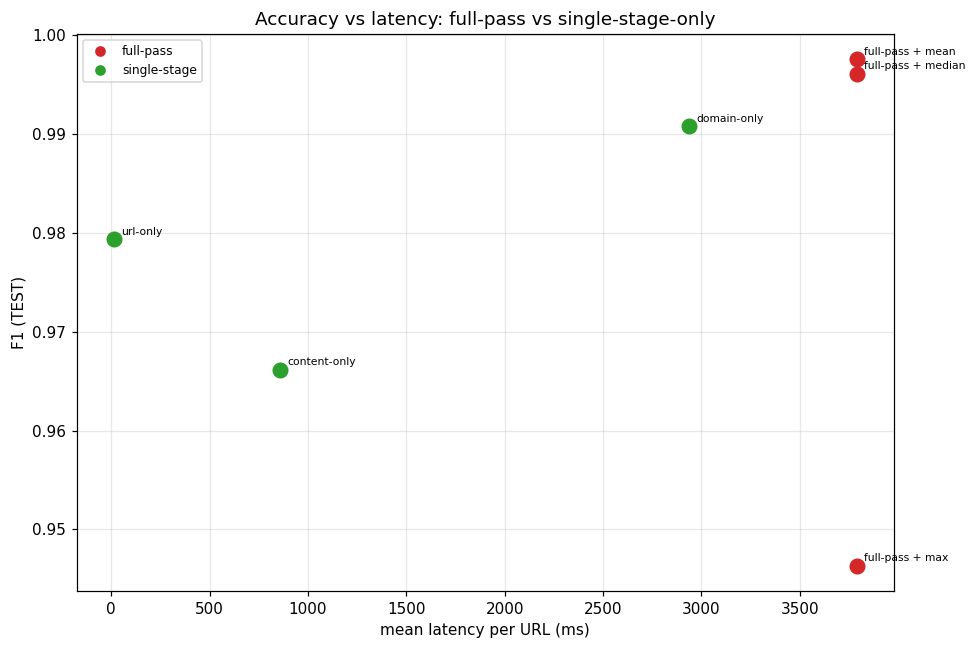

In [12]:
# Accuracy vs latency: each system in (mean latency, F1) space -- full-pass (warm) vs single-stage
# (cool). The dashed line is the best single-stage F1, so the ensemble gain is read off vertically.
COL = {"full-pass": "tab:red", "single-stage": "tab:green"}
fig, ax = plt.subplots(figsize=(9, 6))
for _, r in fullpass.iterrows():
    ax.scatter(r["mean_latency_ms"], r["f1"], s=90, color=COL[r["kind"]], zorder=3)
    ax.annotate(r["system"], (r["mean_latency_ms"], r["f1"]), fontsize=7,
                xytext=(5, 3), textcoords="offset points")
handles = [plt.Line2D([], [], marker="o", ls="", color=COL["full-pass"], label="full-pass"),
           plt.Line2D([], [], marker="o", ls="", color=COL["single-stage"], label="single-stage")]
ax.legend(handles=handles, loc="upper left", fontsize=8)
ax.set_xlabel("mean latency per URL (ms)"); ax.set_ylabel("F1 (TEST)")
ax.set_title("Accuracy vs latency: full-pass vs single-stage-only")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Shared-threshold sweep

The sweep below applies **one shared threshold to every stage** and serves as the baseline curve. The per-stage configuration is evaluated against
it in the following sections.


In [13]:
def evaluate(prob_lists, y_true, threshold):
    preds, routes = [], []
    for L in prob_lists:
        dec, _sid, route = cascade(L, threshold)
        preds.append(1 if dec == POSITIVE else 0)
        routes.append(route)
    preds = np.asarray(preds)
    npos, nben = int((y_true == 1).sum()), int((y_true == 0).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    fn = int(((preds == 0) & (y_true == 1)).sum())
    return {
        "threshold":  threshold,
        "precision":  precision_score(y_true, preds, zero_division=0),
        "recall":     recall_score(y_true, preds, zero_division=0),
        "f1":         f1_score(y_true, preds, zero_division=0),
        "accuracy":   accuracy_score(y_true, preds),
        "fnr":        fn / npos if npos else 0.0,   # missed phish / all phish (= 1 - recall)
        "fpr":        fp / nben if nben else 0.0,   # flagged benign / all benign
        "pred_phish": int(preds.sum()),
        "n_unknown":  int(sum(r == "unknown" for r in routes)),
    }

sweep = pd.DataFrame([evaluate(test_probs, y_test, t) for t in THRESHOLDS])   # test (report/plots)

print("TEST sweep (every 10th threshold):")
print(sweep.iloc[::10][["threshold", "precision", "recall", "f1", "accuracy", "fnr", "fpr", "pred_phish"]]
      .round(4).to_string(index=False))

TEST sweep (every 10th threshold):
 threshold  precision  recall     f1  accuracy    fnr    fpr  pred_phish
       0.0     0.9622  0.9971 0.9793    0.9797 0.0029 0.0365        1059
       0.1     0.9051  0.9980 0.9493    0.9485 0.0020 0.0976        1127
       0.2     0.9011  0.9980 0.9471    0.9462 0.0020 0.1022        1132
       0.3     0.8995  0.9980 0.9462    0.9452 0.0020 0.1040        1134
       0.4     0.8987  0.9980 0.9458    0.9448 0.0020 0.1049        1135
       0.5     0.8981  1.0000 0.9463    0.9452 0.0000 0.1058        1138
       0.6     0.9150  1.0000 0.9556    0.9551 0.0000 0.0867        1117
       0.7     0.9282  1.0000 0.9628    0.9627 0.0000 0.0721        1101
       0.8     0.9642  1.0000 0.9817    0.9821 0.0000 0.0347        1060
       0.9     0.9789  1.0000 0.9894    0.9896 0.0000 0.0201        1044
       1.0     0.9951  0.9990 0.9971    0.9972 0.0010 0.0046        1026


### Metrics & error rates vs. threshold (TEST)

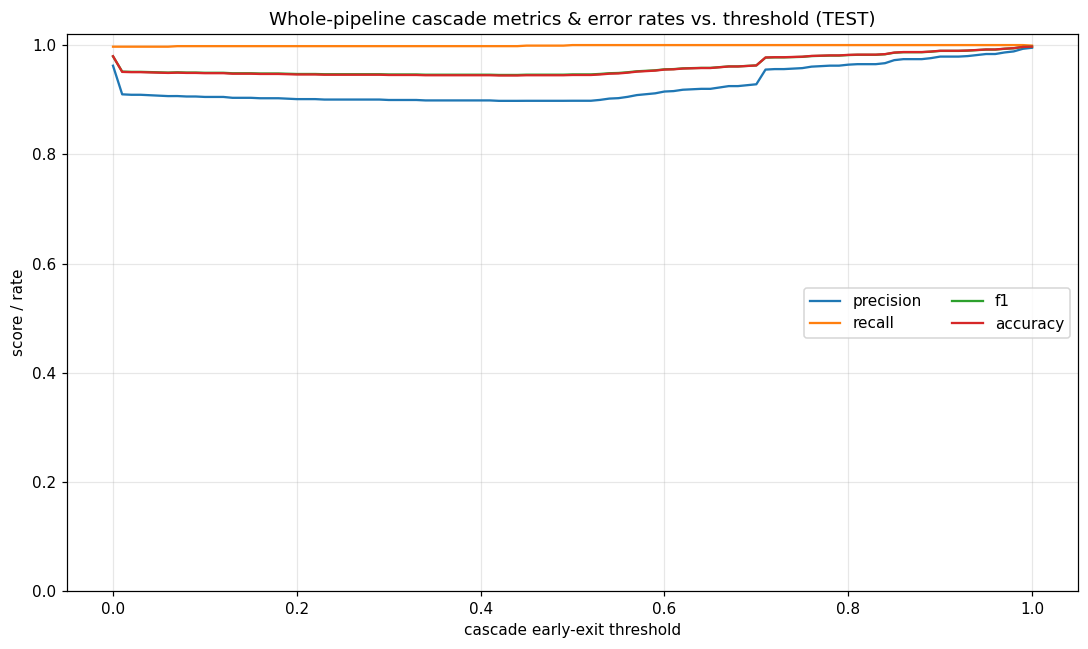

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
for m, c in [("precision", "tab:blue"), ("recall", "tab:orange"),
             ("f1", "tab:green"), ("accuracy", "tab:red")]:
    ax.plot(sweep["threshold"], sweep[m], label=m, color=c)
    
ax.set_xlabel("cascade early-exit threshold"); ax.set_ylabel("score / rate")
ax.set_title("Whole-pipeline cascade metrics & error rates vs. threshold (TEST)")
ax.set_ylim(0, 1.02); ax.grid(alpha=0.3); ax.legend(loc="center right", ncol=2)
plt.tight_layout(); plt.show()

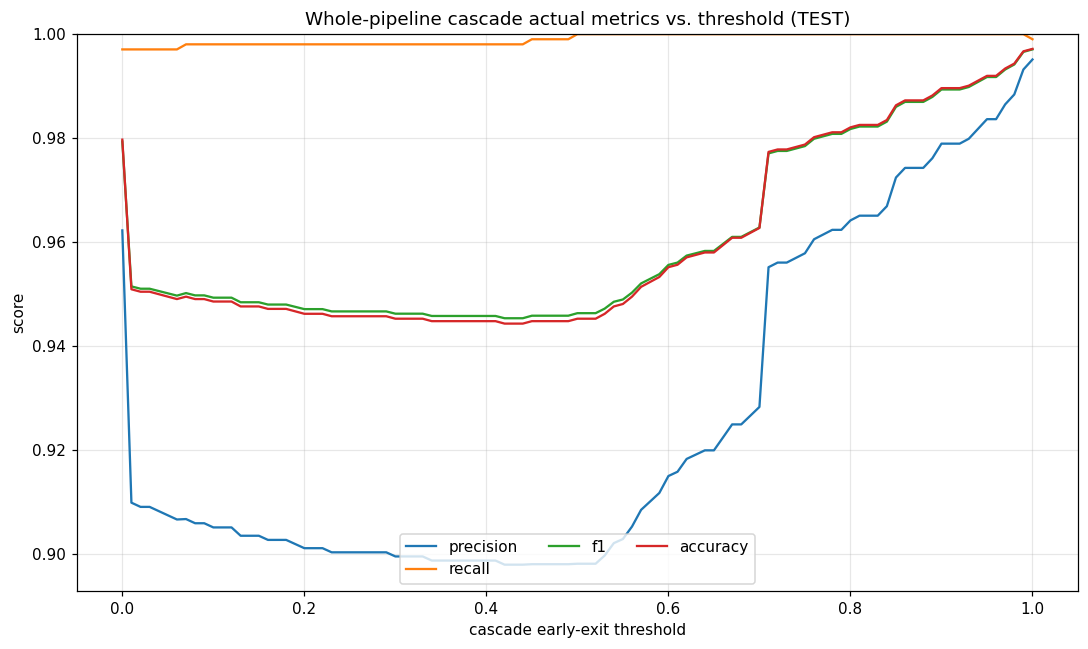

,min,max
precision,0.8979,0.9951
recall,0.9971,1.0000
f1,0.9453,0.9971
accuracy,0.9443,0.9972


In [15]:
# Zoomed view of the headline metrics across thresholds.
metrics = ["precision", "recall", "f1", "accuracy"]
metric_bounds = {m: {"min": float(np.nanmin(sweep[m])), "max": float(np.nanmax(sweep[m]))}
                 for m in metrics}

fig, ax = plt.subplots(figsize=(10, 6))
for m, c in [("precision", "tab:blue"), ("recall", "tab:orange"),
             ("f1", "tab:green"), ("accuracy", "tab:red")]:
    ax.plot(sweep["threshold"], sweep[m], label=m, color=c)
ymin = min(v["min"] for v in metric_bounds.values())
ymax = max(v["max"] for v in metric_bounds.values())
ypad = 0.05 * (ymax - ymin) if not np.isclose(ymax - ymin, 0) else 0.05
ax.set_xlabel("cascade early-exit threshold"); ax.set_ylabel("score")
ax.set_title("Whole-pipeline cascade actual metrics vs. threshold (TEST)")
ax.set_ylim(max(0.0, ymin - ypad), min(1.0, ymax + ypad)); ax.grid(alpha=0.3); ax.legend(loc="lower center", ncol=3)
plt.tight_layout(); plt.show()

pd.DataFrame(metric_bounds).T.round(4)

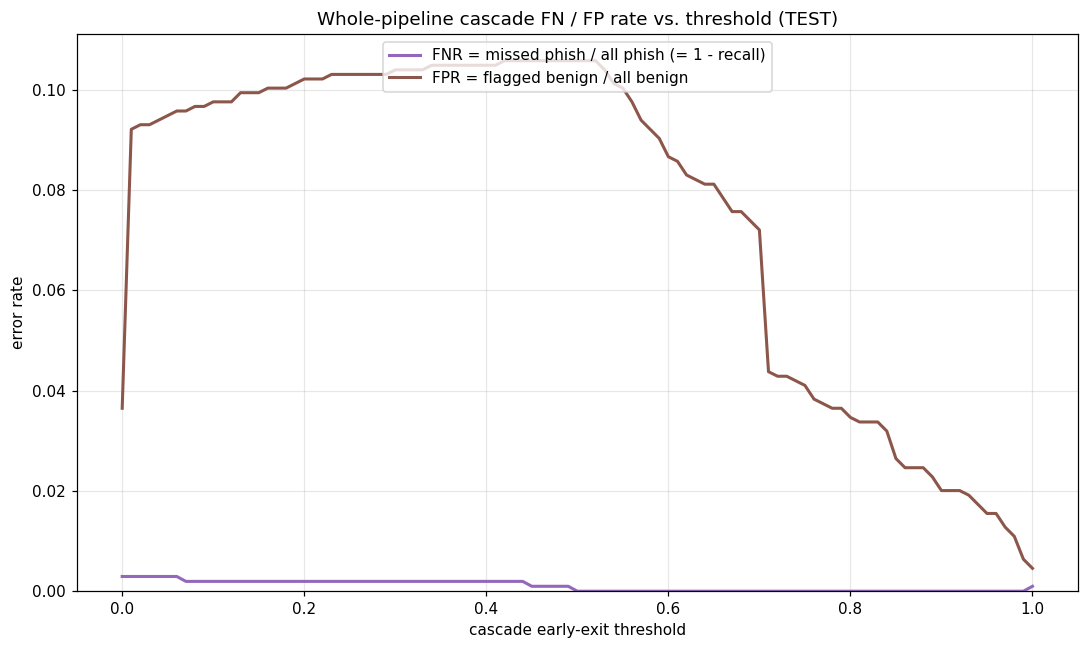

FN / FP rates at representative thresholds (TEST):
              FNR     FPR  recall  precision
threshold                                   
0.00       0.0029  0.0365  0.9971     0.9622
0.50       0.0000  0.1058  1.0000     0.8981
0.90       0.0000  0.0201  1.0000     0.9789
0.99       0.0000  0.0064  1.0000     0.9932
1.00       0.0010  0.0046  0.9990     0.9951


,FNR,FPR,recall,precision
threshold,,,,
0.00,0.0029,0.0365,0.9971,0.9622
0.50,0.0000,0.1058,1.0000,0.8981
0.90,0.0000,0.0201,1.0000,0.9789
0.99,0.0000,0.0064,1.0000,0.9932
1.00,0.0010,0.0046,0.9990,0.9951


In [16]:
# Dedicated false-negative / false-positive rate analysis (their own scale, both are small).
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sweep["threshold"], sweep["fnr"], color="tab:purple", lw=2,
        label="FNR = missed phish / all phish (= 1 - recall)")
ax.plot(sweep["threshold"], sweep["fpr"], color="tab:brown", lw=2,
        label="FPR = flagged benign / all benign")
ax.set_xlabel("cascade early-exit threshold"); ax.set_ylabel("error rate")
ax.set_ylim(bottom=0); ax.grid(alpha=0.3); ax.legend(loc="upper center")
ax.set_title("Whole-pipeline cascade FN / FP rate vs. threshold (TEST)")
plt.tight_layout(); plt.show()

# error rates at a few representative thresholds
def _erow(t):
    i = int((sweep["threshold"] - t).abs().idxmin())
    return sweep.iloc[i]
reps = sorted({0.0, 0.5, 0.9, 0.99, 1.0})
err_tbl = pd.DataFrame([
    {"threshold": _erow(t)["threshold"], "FNR": _erow(t)["fnr"], "FPR": _erow(t)["fpr"],
     "recall": _erow(t)["recall"], "precision": _erow(t)["precision"]}
    for t in reps
]).set_index("threshold")
print("FN / FP rates at representative thresholds (TEST):")
print(err_tbl.round(4).to_string())
err_tbl.round(4)

### Predictions composition vs threshold

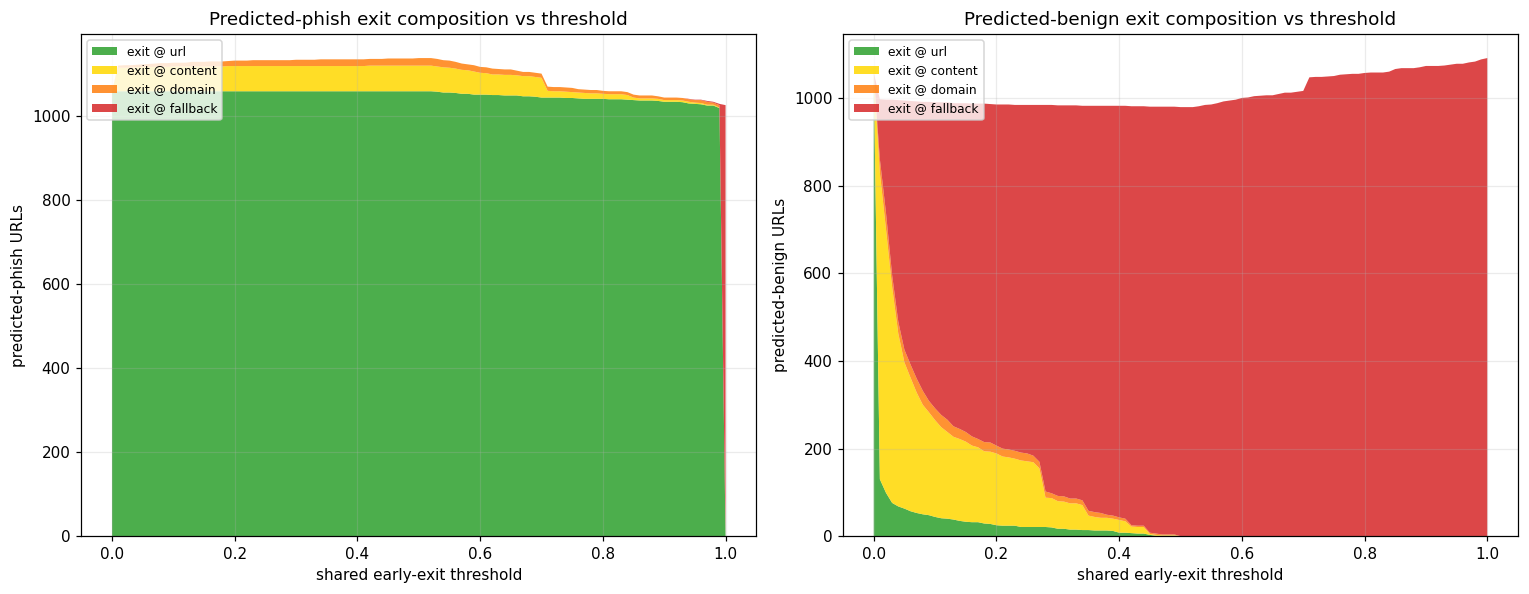

mean stages traversed: min 1.000 (t=0.00) -> max 2.979 (t=1.00)
benign exits at fallback: t=0.0 -> 0  |  t=1.0 -> 1092  (benign escalate fully once thr>0.5)


In [17]:
# Cost across the shared-threshold sweep: how phish- AND benign-exit composition shift.
rows = []
for t in THRESHOLDS:
    cb = cost_breakdown(t)
    ph, be = cb["phish_hist"], cb["benign_hist"]
    rows.append({"threshold": t, "mean_stages": cb["mean_stages"],
                 "mean_phish_depth": cb["mean_phish_depth"],
                 **{f"phish_{k}": ph.get(k, 0) for k in EXIT_POINTS},
                 **{f"benign_{k}": be.get(k, 0) for k in EXIT_POINTS}})
cost = pd.DataFrame(rows)
costsweep = sweep.merge(cost, on="threshold")
costsweep.to_csv("eval_results/pipeline_cost_stages_sweep.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
for ax, kind, ylab in [(axes[0], "phish", "predicted-phish URLs"),
                       (axes[1], "benign", "predicted-benign URLs")]:
    ax.stackplot(costsweep["threshold"],
                 *[costsweep[f"{kind}_{p}"] for p in EXIT_POINTS],
                 labels=[f"exit @ {p}" for p in EXIT_POINTS],
                 colors=["tab:green", "gold", "tab:orange", "tab:red"], alpha=0.85)
    ax.set_xlabel("shared early-exit threshold"); ax.set_ylabel(ylab)
    ax.grid(alpha=0.25); ax.legend(loc="upper left", fontsize=8)
axes[0].set_title("Predicted-phish exit composition vs threshold")
axes[1].set_title("Predicted-benign exit composition vs threshold")
plt.tight_layout(); plt.show()
print("mean stages traversed: min %.3f (t=%.2f) -> max %.3f (t=%.2f)"
      % (costsweep["mean_stages"].min(), costsweep.loc[costsweep["mean_stages"].idxmin(), "threshold"],
         costsweep["mean_stages"].max(), costsweep.loc[costsweep["mean_stages"].idxmax(), "threshold"]))
print("benign exits at fallback: t=0.0 -> %d  |  t=1.0 -> %d  (benign escalate fully once thr>0.5)"
      % (int(costsweep.loc[costsweep['threshold']==0.0, 'benign_fallback'].iloc[0]),
         int(costsweep.loc[costsweep['threshold']==1.0, 'benign_fallback'].iloc[0])))


### Composition of FP and FN with shared single threshold

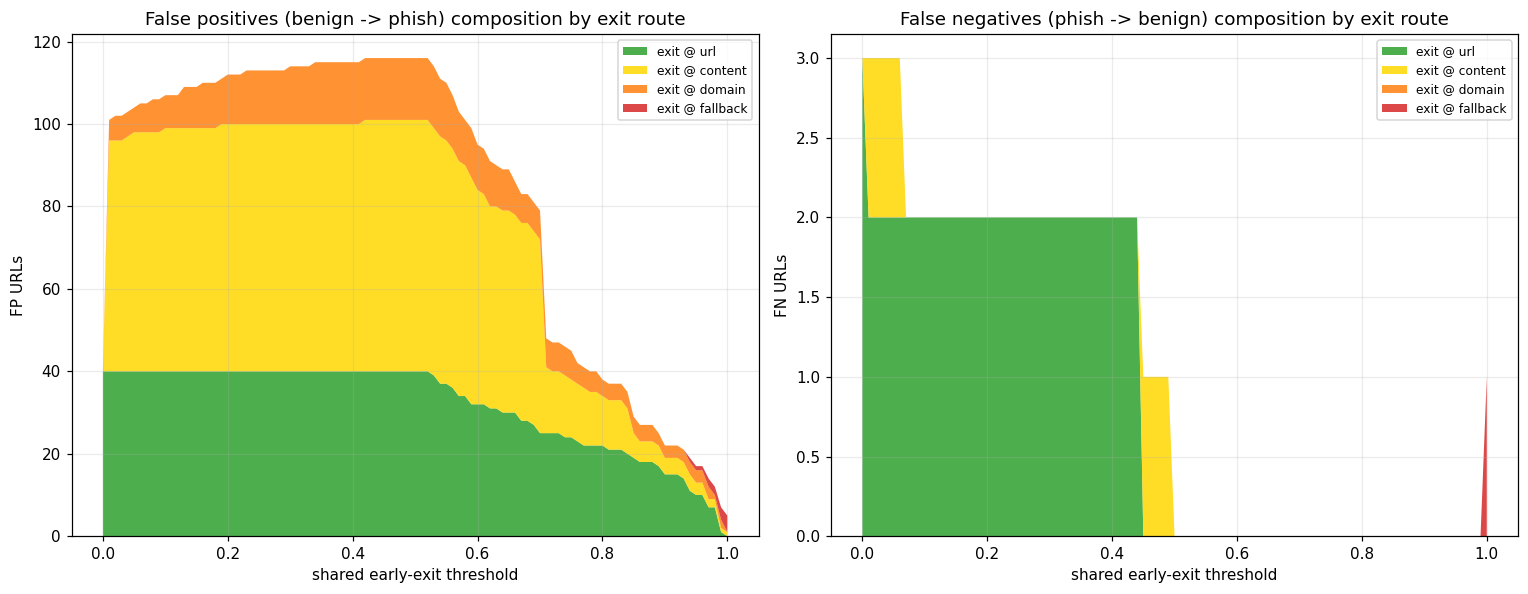

total FP across thresholds: 5-116 | total FN: 0-3 (FN ~ negligible -> the errors that matter are almost all FP)
saved -> eval_results/pipeline_outcome_by_exit_sweep.csv


In [18]:
# Outcome (TP/FP/FN/TN) by exit point across the FULL shared-threshold sweep.
OC = ["TP", "FP", "FN", "TN"]
cube = np.zeros((len(THRESHOLDS), len(EXIT_POINTS), len(OC)), dtype=int)
for ti, t in enumerate(THRESHOLDS):
    cube[ti] = outcome_by_exit(t)[OC].to_numpy()

# full counts saved; the plots focus on the errors -- TP/TN are the easy correct mass.
recs = [{"threshold": float(THRESHOLDS[ti]), "exit": EXIT_POINTS[ei], "outcome": OC[oi],
         "n": int(cube[ti, ei, oi])}
        for ti in range(len(THRESHOLDS)) for ei in range(len(EXIT_POINTS)) for oi in range(len(OC))]
pd.DataFrame(recs).to_csv("eval_results/pipeline_outcome_by_exit_sweep.csv", index=False)

# 1) Error COMPOSITION by exit route vs threshold (stacked, like the exit-composition plots):
#    stack height = total FP / FN; each band = that exit route's contribution.
fp = cube[:, :, OC.index("FP")]
fn = cube[:, :, OC.index("FN")]
EXIT_COLORS = ["tab:green", "gold", "tab:orange", "tab:red"]   # url, content, domain, fallback
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
for ax, arr, title, ylab in [(axes[0], fp, "False positives (benign -> phish)", "FP URLs"),
                             (axes[1], fn, "False negatives (phish -> benign)", "FN URLs")]:
    ax.stackplot(THRESHOLDS, *[arr[:, ei] for ei in range(len(EXIT_POINTS))],
                 labels=[f"exit @ {p}" for p in EXIT_POINTS], colors=EXIT_COLORS, alpha=0.85)
    ax.set_title(f"{title} composition by exit route"); ax.set_xlabel("shared early-exit threshold")
    ax.set_ylabel(ylab); ax.grid(alpha=0.25); ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

print(f"total FP across thresholds: {int(fp.sum(1).min())}-{int(fp.sum(1).max())} | "
      f"total FN: {int(fn.sum(1).min())}-{int(fn.sum(1).max())} "
      f"(FN ~ negligible -> the errors that matter are almost all FP)")
print("saved -> eval_results/pipeline_outcome_by_exit_sweep.csv")


## Latency vs. F1 trade-off (uses measured per-stage mean latency)

Combines this notebook's **F1-vs-threshold** sweep with the **per-stage mean latency** measured by
`latency_evaluation.ipynb` (read from `eval_results/latency_summary.csv`) to estimate the **expected
end-to-end latency per URL** as the cascade threshold varies.

For each URL we walk the **production cascade order** (`config.pipeline.stages` = url -> content ->
domain) and add a stage's mean latency for every stage it *visits*, stopping at the first stage whose
`P(phish) >= threshold` (early-exit). Raising the threshold makes fewer URLs early-exit, so more
escalate to the expensive `content`/`domain` stages -> higher latency. F1 is order-independent (it
only depends on whether *any* stage crosses the threshold), so the existing sweep is reused as-is and
each URL's stage list is just reordered into production order for the latency walk.

In [19]:
# Latency-vs-F1 trade-off table: join the one-sided shared-threshold sweep with expected per-URL latency.
tradeoff = sweep.merge(
    pd.DataFrame([{"threshold": t, **latency_stats(t)} for t in THRESHOLDS]), on="threshold")
print("trade-off table (every 10th shared threshold):")
print(tradeoff[["threshold", "precision", "recall", "f1", "mean_latency_ms"]]
      .iloc[::10].round(3).to_string(index=False))

trade-off table (every 10th shared threshold):
 threshold  precision  recall    f1  mean_latency_ms
       0.0      0.962   0.997 0.979           13.450
       0.1      0.905   0.998 0.949         1427.742
       0.2      0.901   0.998 0.947         1539.010
       0.3      0.899   0.998 0.946         1693.373
       0.4      0.899   0.998 0.946         1756.633
       0.5      0.898   1.000 0.946         1809.783
       0.6      0.915   1.000 0.956         1835.780
       0.7      0.928   1.000 0.963         1854.845
       0.8      0.964   1.000 0.982         1908.745
       0.9      0.979   1.000 0.989         1932.374
       1.0      0.995   0.999 0.997         3787.634


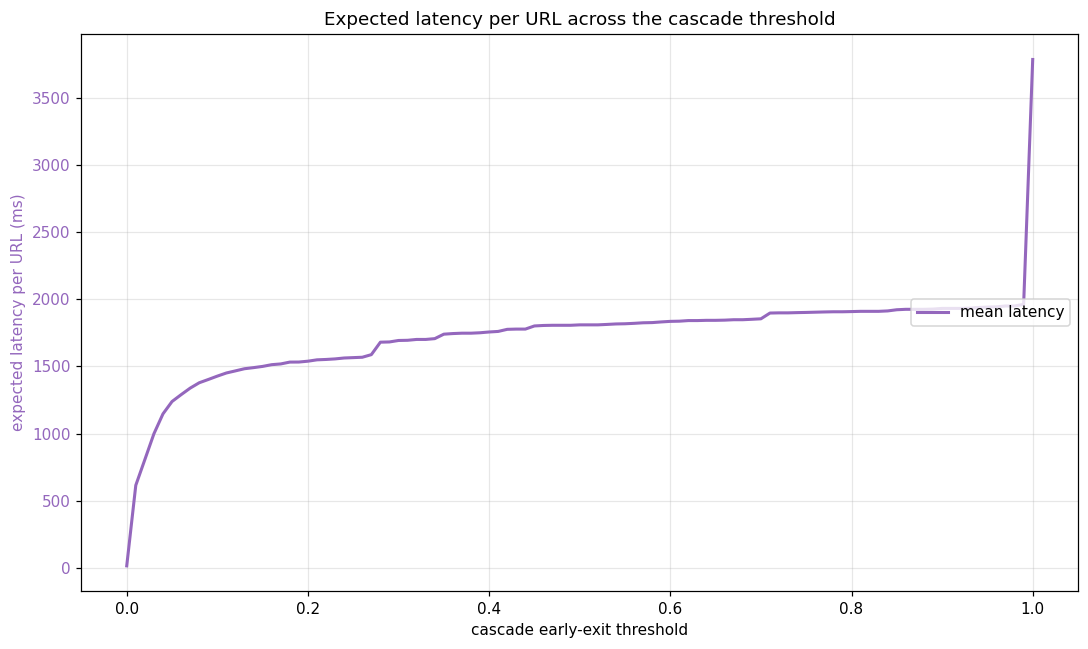

In [20]:
# Expected latency across the threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(tradeoff["threshold"], tradeoff["mean_latency_ms"], color="tab:purple", lw=2, label="mean latency")
ax.set_xlabel("cascade early-exit threshold")
ax.set_ylabel("expected latency per URL (ms)", color="tab:purple")
ax.tick_params(axis="y", labelcolor="tab:purple"); ax.grid(alpha=0.3)
ax.legend(loc="center right")
ax.set_title("Expected latency per URL across the cascade threshold")
plt.tight_layout(); plt.show()

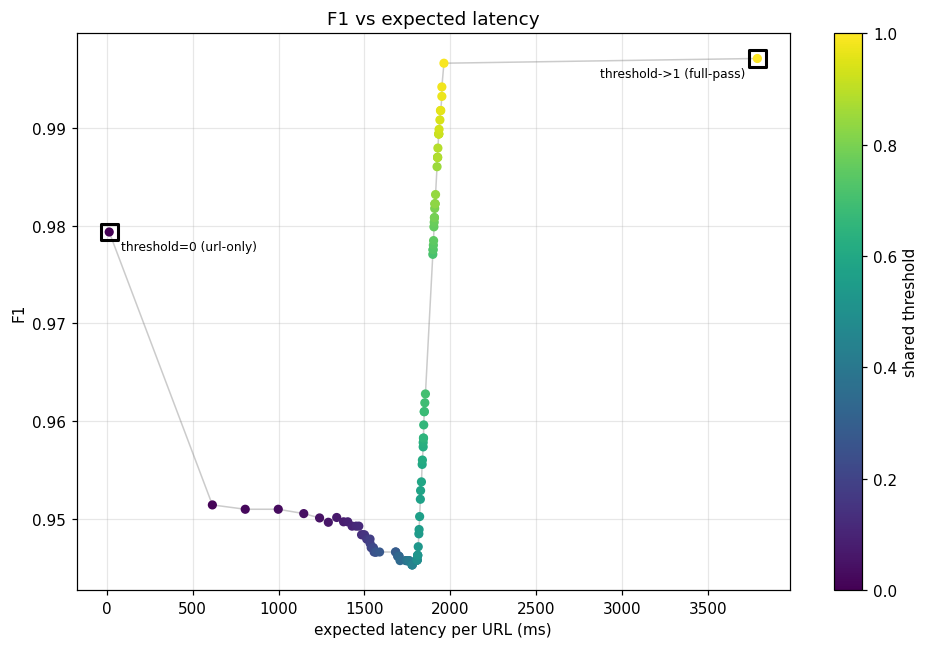

In [21]:
# Pareto view: F1 vs expected latency. Shared-threshold sweep (points colored by threshold),
# plus the two per-stage operating points.
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(tradeoff["mean_latency_ms"], tradeoff["f1"], color="tab:gray", alpha=0.4, lw=1, zorder=3)
sc = ax.scatter(tradeoff["mean_latency_ms"], tradeoff["f1"], c=tradeoff["threshold"],
                cmap="viridis", s=25, zorder=4, label="shared threshold sweep")
plt.colorbar(sc, label="shared threshold")
# endpoints of the band sweep.
for x, ylab, ha, dx in [(0, "threshold=0 (url-only)", "left", 8), (-1, "threshold->1 (full-pass)", "right", -8)]:
    ax.scatter([tradeoff["mean_latency_ms"].iloc[x]], [tradeoff["f1"].iloc[x]], s=120, marker="s",
               edgecolor="black", facecolor="none", lw=2, zorder=5)
    ax.annotate(ylab, (tradeoff["mean_latency_ms"].iloc[x], tradeoff["f1"].iloc[x]),
                fontsize=8, ha=ha, xytext=(dx, -12), textcoords="offset points")

ax.set_xlabel("expected latency per URL (ms)"); ax.set_ylabel("F1")
ax.set_title("F1 vs expected latency")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [22]:
tradeoff.to_csv("eval_results/latency_f1_tradeoff.csv", index=False)
print(f"saved {len(tradeoff)} rows -> eval_results/latency_f1_tradeoff.csv")

saved 101 rows -> eval_results/latency_f1_tradeoff.csv


## Per-stage deferral band (selective cascade with a reject region)

The cascade so far early-exits on a **single** bar: a stage decides when `P(phish) >= threshold`.
Because every shipped threshold is `> 0.5`, that bar is **one-sided** -- a stage can only ever
short-circuit to **phish**; a stage that is confident a URL is *benign* (`P(phish) ~ 0`) still
escalates, so every benign URL pays the full cascade (see the benign-exit histogram above, where
benign piles up at `fallback`).

This section evaluates a **two-sided** rule. Each stage carries a **deferral band**
`[0.5 - delta, 0.5 + delta]` around the 0.5 boundary:

- `P(phish) <= 0.5 - delta` -> confident **benign** -> early-exit with the stage's own verdict,
- `P(phish) >= 0.5 + delta` -> confident **phish**  -> early-exit with the stage's own verdict,
- in between -> **defer** -> escalate to the next stage.

This is *classification with a reject option* (selective prediction): the band is the abstain region
and escalation = "defer to a stronger stage". The half-width `delta in [0, 0.5]` is a single
**deferral margin** dial:

- `delta = 0`   -> no abstention; the first stage always decides  (== **url-only**),
- `delta -> 0.5` -> everything escalates; the verdict is the aggregate of all stages (== **full-pass**).

It strictly generalizes the one-sided cascade (which is the special case "lower edge = 0"); the new
power is that **confident-benign can now exit at the cheap `url` stage** -- which is where the latency
on the benign majority is won.

**Two knobs, not one.** The **lower edge** `0.5 - delta` is a false-negative dial (how sure a cheap
stage must be before it clears a URL as benign); the **upper edge** `0.5 + delta` is a false-positive
dial (how sure before it flags phish). The symmetric sweep below moves them together; the asymmetric
grid at the end separates them -- relevant because in phishing a missed phish usually costs more than
a false alarm.

In [23]:
# --- Two-sided deferral-band cascade (reject region around the 0.5 boundary) -----------------
# A stage early-exits when P(phish) is OUTSIDE its band [lo, hi] (confident either way), adopting its
# own model verdict via the SAME _build_result as production; a probability INSIDE the band is
# deferred and escalates. We replay in PRODUCTION order (test_probs_ord) because, unlike the
# one-sided sweep, a benign early-exit makes the band's verdict order-dependent.

def _delta_for(deltas, sid):
    '''delta for one stage: a scalar shared by all stages, or {stage_id: delta} (opt "_default").'''
    if isinstance(deltas, dict):
        v = deltas.get(sid)
        return v if v is not None else deltas.get("_default", 0.0)
    return float(deltas)

def sym_band(deltas):
    '''symmetric half-width -> band_of(sid)=(lo,hi). `deltas` scalar or per-stage map.'''
    return lambda sid: (0.5 - _delta_for(deltas, sid), 0.5 + _delta_for(deltas, sid))

def asym_band(d_lo, d_hi):
    '''asymmetric edges shared by all stages: benign side 0.5-d_lo, phish side 0.5+d_hi.'''
    return lambda sid: (0.5 - d_lo, 0.5 + d_hi)

def band_pass(prob_list_ord, band_of):
    '''One production-order pass. band_of(sid)->(lo,hi); a stage exits when p<=lo or p>=hi.
    Returns (pred 0/1, exit_point, n_stages_run, latency_ms). Verdict via _build_result so the
    early-exit / aggregation semantics match Pipeline.run exactly.'''
    collected, early, lat = [], None, 0.0
    for sid, p in prob_list_ord:
        collected.append((sid, p)); lat += LAT_MS.get(sid, 0.0)
        lo, hi = band_of(sid)
        if p <= lo or p >= hi:                 # outside the band -> confident -> stop here
            early = (sid, p); break
    dec = _replay._build_result(_ctx, collected, early).decision
    where = early[0] if early is not None else "fallback"
    return (1 if dec == POSITIVE else 0), where, len(collected), lat

def band_metrics(band_of):
    '''Full metrics + mean latency + per-URL exit points for one band, on the TEST split.'''
    n = len(test_probs_ord)
    preds = np.empty(n, dtype=int); lat = np.empty(n); exits = []
    for k, L in enumerate(test_probs_ord):
        preds[k], where, _ns, lat[k] = band_pass(L, band_of); exits.append(where)
    npos, nben = int((y_test == 1).sum()), int((y_test == 0).sum())
    fp = int(((preds == 1) & (y_test == 0)).sum()); fn = int(((preds == 0) & (y_test == 1)).sum())
    return {"precision": precision_score(y_test, preds, zero_division=0),
            "recall":    recall_score(y_test, preds, zero_division=0),
            "f1":        f1_score(y_test, preds, zero_division=0),
            "accuracy":  accuracy_score(y_test, preds),
            "fnr": fn / npos if npos else 0.0, "fpr": fp / nben if nben else 0.0,
            "mean_latency_ms": float(lat.mean()), "preds": preds, "exits": exits}

# sanity: delta=0 must reproduce url-only exactly; delta->0.5 approaches full-pass + mean aggregation
# (modulo URLs whose early stage saturates to exactly 0.0/1.0, which stay outside any band).
_m0 = band_metrics(sym_band(0.0))
_url_only = np.asarray([1 if (L and L[0][1] >= 0.5) else 0 for L in test_probs_ord])
print(f"delta=0 == url-only        : {bool((_m0['preds'] == _url_only).all())}  "
      f"(F1={_m0['f1']:.4f}, mean_latency={_m0['mean_latency_ms']:.1f} ms)")
_mf = band_metrics(sym_band(0.4999))
_fp_mean = np.asarray([_agg_decode(L, "mean") for L in test_probs_ord])
print(f"delta->0.5 ~ full-pass+mean : agree={float((_mf['preds'] == _fp_mean).mean()):.4f}  "
      f"(F1={_mf['f1']:.4f}, mean_latency={_mf['mean_latency_ms']:.1f} ms, "
      f"still exiting on saturated scores={sum(w != 'fallback' for w in _mf['exits'])})")

delta=0 == url-only        : True  (F1=0.9793, mean_latency=13.4 ms)
delta->0.5 ~ full-pass+mean : agree=0.9991  (F1=0.9976, mean_latency=2583.5 ms, still exiting on saturated scores=817)


In [24]:
# Symmetric sweep: widen the band from delta=0 (url-only) to delta=0.5 (~full-pass), shared by all stages.
DELTAS = np.round(np.linspace(0.0, 0.5, 51), 4)
_rows, band_exit_hist = [], {}
for d in DELTAS:
    m = band_metrics(sym_band(float(d)))
    _rows.append({"delta": float(d),
                  **{k: m[k] for k in ("precision", "recall", "f1", "accuracy", "fnr", "fpr", "mean_latency_ms")}})
    band_exit_hist[float(d)] = Counter(m["exits"])
band_sweep = pd.DataFrame(_rows)

bd = band_sweep.loc[band_sweep["f1"].idxmax()]
print(f"best symmetric band: delta={bd['delta']:.3f}  F1={bd['f1']:.4f}  "
      f"P={bd['precision']:.4f} R={bd['recall']:.4f}  mean_latency={bd['mean_latency_ms']:.1f} ms")
print("\nband sweep (every 5th delta):")
print(band_sweep.iloc[::5][["delta", "precision", "recall", "f1", "fnr", "fpr", "mean_latency_ms"]]
      .round(4).to_string(index=False))

best symmetric band: delta=0.490  F1=0.9976  P=0.9961 R=0.9990  mean_latency=261.0 ms

band sweep (every 5th delta):
 delta  precision  recall     f1    fnr    fpr  mean_latency_ms
  0.00     0.9622  0.9971 0.9793 0.0029 0.0365          13.4500
  0.05     0.9650  0.9971 0.9808 0.0029 0.0338          15.8772
  0.10     0.9687  0.9980 0.9831 0.0020 0.0301          23.2729
  0.15     0.9705  0.9980 0.9841 0.0020 0.0283          27.8956
  0.20     0.9761  0.9990 0.9874 0.0010 0.0228          37.6597
  0.25     0.9770  0.9990 0.9879 0.0010 0.0219          41.0688
  0.30     0.9789  0.9990 0.9889 0.0010 0.0201          46.2690
  0.35     0.9817  0.9990 0.9903 0.0010 0.0173          58.6332
  0.40     0.9855  0.9990 0.9922 0.0010 0.0137          79.9524
  0.45     0.9893  0.9990 0.9942 0.0010 0.0100         119.7593
  0.50     0.9951  0.9990 0.9971 0.0010 0.0046        3661.4639


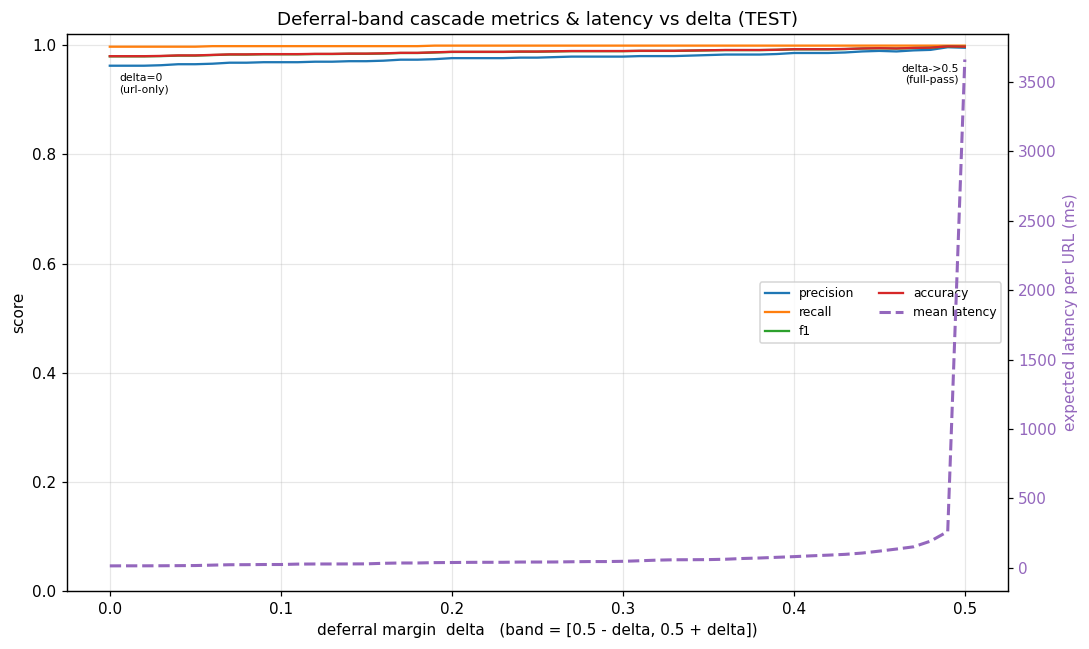

In [25]:
# Metrics vs the deferral margin (delta), with expected latency on a twin axis.
fig, ax = plt.subplots(figsize=(10, 6))
for mname, c in [("precision", "tab:blue"), ("recall", "tab:orange"),
                 ("f1", "tab:green"), ("accuracy", "tab:red")]:
    ax.plot(band_sweep["delta"], band_sweep[mname], label=mname, color=c)
ax.set_xlabel("deferral margin  delta   (band = [0.5 - delta, 0.5 + delta])")
ax.set_ylabel("score"); ax.set_ylim(0, 1.02); ax.grid(alpha=0.3)
axl = ax.twinx()
axl.plot(band_sweep["delta"], band_sweep["mean_latency_ms"], color="tab:purple", lw=2, ls="--", label="mean latency")
axl.set_ylabel("expected latency per URL (ms)", color="tab:purple")
axl.tick_params(axis="y", labelcolor="tab:purple")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axl.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="center right", ncol=2, fontsize=8)
ax.set_title("Deferral-band cascade metrics & latency vs delta (TEST)")
ax.annotate("delta=0\n(url-only)", (0.0, band_sweep["f1"].iloc[0]),
            fontsize=7, xytext=(6, -24), textcoords="offset points")
ax.annotate("delta->0.5\n(full-pass)", (0.5, band_sweep["f1"].iloc[-1]),
            fontsize=7, ha="right", xytext=(-4, -24), textcoords="offset points")
plt.tight_layout(); plt.show()

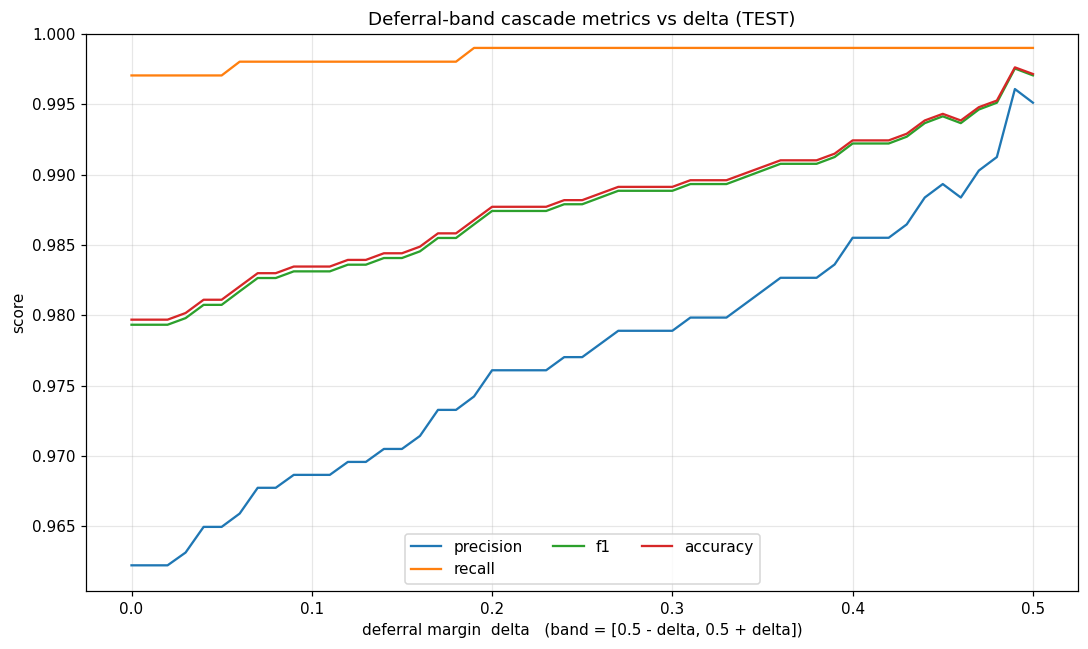

,min,max
precision,0.9622,0.9961
recall,0.9971,0.9990
f1,0.9793,0.9976
accuracy,0.9797,0.9976


In [26]:
# Zoomed view of the deferral-band metrics across delta (latency twin axis dropped for clarity).
bmetrics = ["precision", "recall", "f1", "accuracy"]
bbounds = {m: {"min": float(np.nanmin(band_sweep[m])), "max": float(np.nanmax(band_sweep[m]))}
           for m in bmetrics}
fig, ax = plt.subplots(figsize=(10, 6))
for m, c in [("precision", "tab:blue"), ("recall", "tab:orange"),
             ("f1", "tab:green"), ("accuracy", "tab:red")]:
    ax.plot(band_sweep["delta"], band_sweep[m], label=m, color=c)
ymin = min(v["min"] for v in bbounds.values()); ymax = max(v["max"] for v in bbounds.values())
ypad = 0.05 * (ymax - ymin) if not np.isclose(ymax - ymin, 0) else 0.05
ax.set_xlabel("deferral margin  delta   (band = [0.5 - delta, 0.5 + delta])"); ax.set_ylabel("score")
ax.set_title("Deferral-band cascade metrics vs delta (TEST)")
ax.set_ylim(max(0.0, ymin - ypad), min(1.0, ymax + ypad)); ax.grid(alpha=0.3)
ax.legend(loc="lower center", ncol=3)
plt.tight_layout(); plt.show()

pd.DataFrame(bbounds).T.round(4)

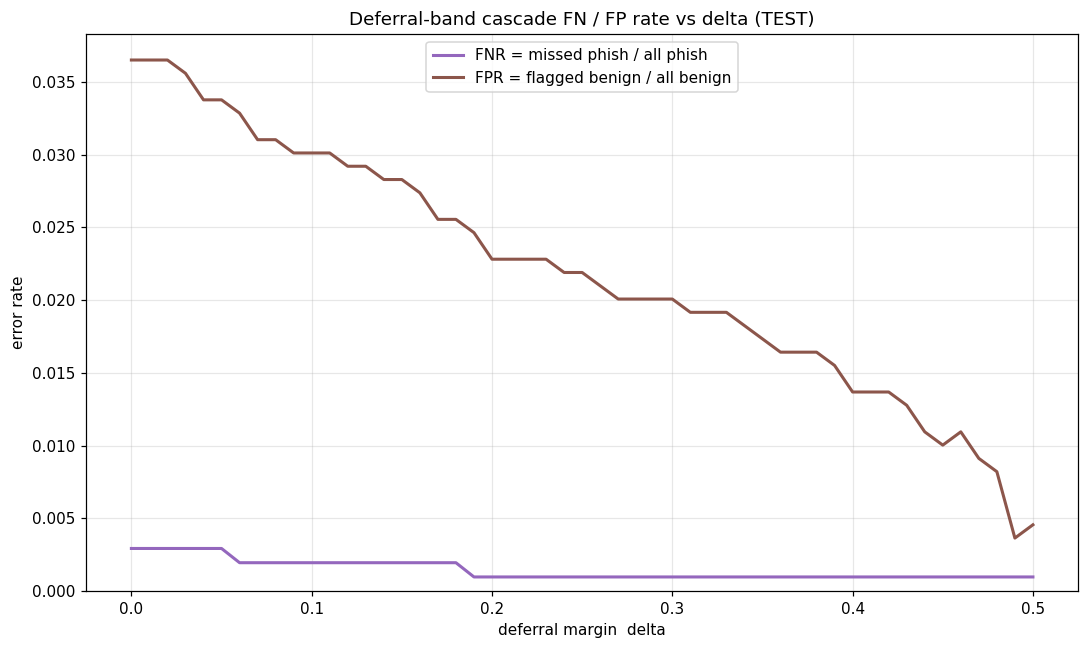

In [27]:
# The two edges as error dials: lower edge (benign exits) drives FNR, upper edge (phish exits) drives FPR.
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(band_sweep["delta"], band_sweep["fnr"], color="tab:purple", lw=2, label="FNR = missed phish / all phish")
ax.plot(band_sweep["delta"], band_sweep["fpr"], color="tab:brown", lw=2, label="FPR = flagged benign / all benign")
ax.set_xlabel("deferral margin  delta"); ax.set_ylabel("error rate")
ax.set_ylim(bottom=0); ax.grid(alpha=0.3); ax.legend(loc="upper center")
ax.set_title("Deferral-band cascade FN / FP rate vs delta (TEST)")
plt.tight_layout(); plt.show()

### Predicted exit composition vs band width

Where predicted-phish and predicted-benign URLs exit the cascade as the deferral margin `delta` widens
-- the band analog of the one-sided "predictions composition vs threshold" plot above.

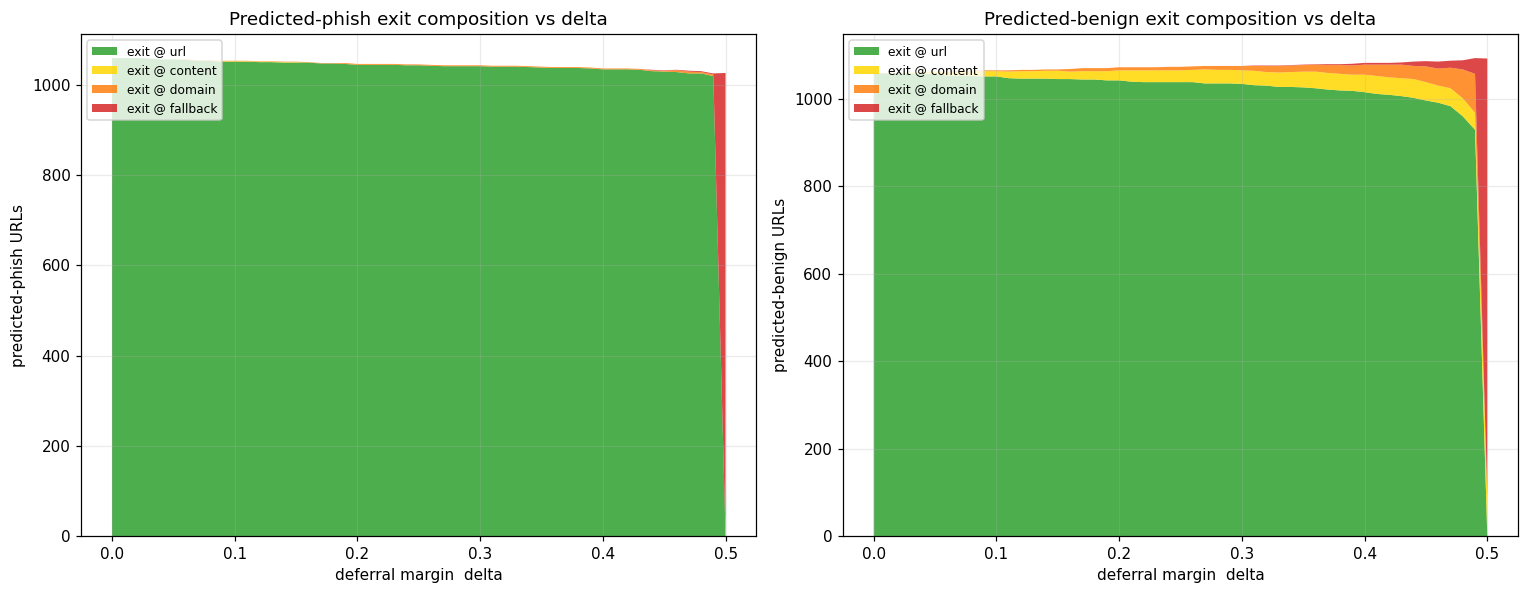

In [28]:
# Predicted-phish / predicted-benign exit composition across the deferral-band sweep -- the band
# analog of the one-sided "predictions composition vs threshold" plot, over the margin delta.
band_cost_rows = []
for d in DELTAS:
    mm = band_metrics(sym_band(float(d)))
    ph = Counter(w for w, pr in zip(mm["exits"], mm["preds"]) if pr == 1)
    be = Counter(w for w, pr in zip(mm["exits"], mm["preds"]) if pr == 0)
    band_cost_rows.append({"delta": float(d),
                           **{f"phish_{p}": ph.get(p, 0) for p in EXIT_POINTS},
                           **{f"benign_{p}": be.get(p, 0) for p in EXIT_POINTS}})
band_cost = pd.DataFrame(band_cost_rows)
band_cost.to_csv("eval_results/pipeline_band_exit_composition_split.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
for ax, kind, ylab in [(axes[0], "phish", "predicted-phish URLs"),
                       (axes[1], "benign", "predicted-benign URLs")]:
    ax.stackplot(band_cost["delta"], *[band_cost[f"{kind}_{p}"] for p in EXIT_POINTS],
                 labels=[f"exit @ {p}" for p in EXIT_POINTS],
                 colors=["tab:green", "gold", "tab:orange", "tab:red"], alpha=0.85)
    ax.set_xlabel("deferral margin  delta"); ax.set_ylabel(ylab)
    ax.grid(alpha=0.25); ax.legend(loc="upper left", fontsize=8)
axes[0].set_title("Predicted-phish exit composition vs delta")
axes[1].set_title("Predicted-benign exit composition vs delta")
plt.tight_layout(); plt.show()

### Composition of FP and FN across the band

False positives and false negatives by exit route across the `delta` sweep -- the band analog of the
one-sided FP/FN-by-exit plot. Stack height is the total error count; each colored band is one exit
route's share.

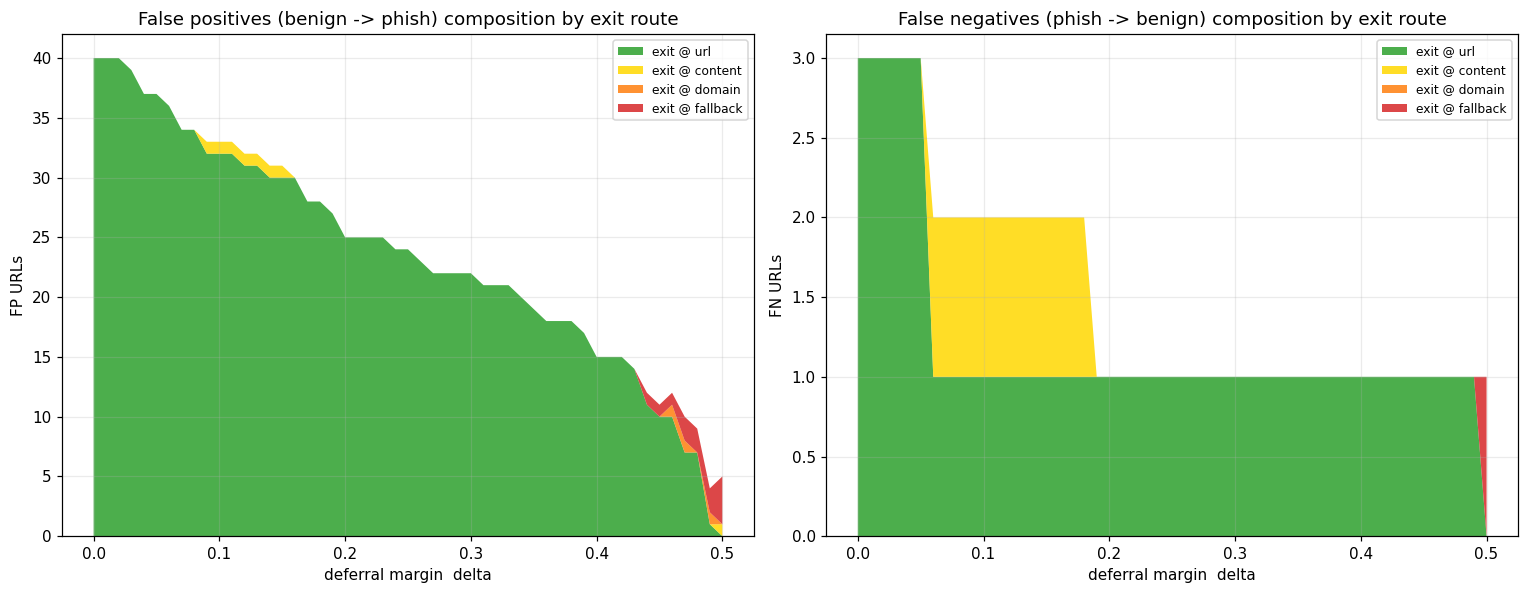

total FP across delta: 4-40 | total FN: 1-3


In [29]:
# False positives / false negatives by exit route across the deferral-band sweep -- the band analog
# of the one-sided FP/FN-by-exit plot. Stack height = total FP / FN; each band = that exit route.
def _band_outcome_by_exit(band_of):
    cats = ["TP", "FP", "FN", "TN"]
    tab = {p: {c: 0 for c in cats} for p in EXIT_POINTS}
    for k, L in enumerate(test_probs_ord):
        pred, where, _n, _lat = band_pass(L, band_of)
        yt = int(y_test[k])
        cat = ("TP" if (pred and yt) else "FP" if (pred and not yt)
               else "FN" if (not pred and yt) else "TN")
        tab[where][cat] += 1
    return pd.DataFrame(tab).T.reindex(EXIT_POINTS)[cats]

OCb = ["TP", "FP", "FN", "TN"]
cube_b = np.zeros((len(DELTAS), len(EXIT_POINTS), len(OCb)), dtype=int)
for di, d in enumerate(DELTAS):
    cube_b[di] = _band_outcome_by_exit(sym_band(float(d)))[OCb].to_numpy()
recs = [{"delta": float(DELTAS[di]), "exit": EXIT_POINTS[ei], "outcome": OCb[oi],
         "n": int(cube_b[di, ei, oi])}
        for di in range(len(DELTAS)) for ei in range(len(EXIT_POINTS)) for oi in range(len(OCb))]
pd.DataFrame(recs).to_csv("eval_results/pipeline_band_outcome_by_exit_sweep.csv", index=False)

fpb = cube_b[:, :, OCb.index("FP")]; fnb = cube_b[:, :, OCb.index("FN")]
EXIT_COLORS = ["tab:green", "gold", "tab:orange", "tab:red"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
for ax, arr, title, ylab in [(axes[0], fpb, "False positives (benign -> phish)", "FP URLs"),
                             (axes[1], fnb, "False negatives (phish -> benign)", "FN URLs")]:
    ax.stackplot(DELTAS, *[arr[:, ei] for ei in range(len(EXIT_POINTS))],
                 labels=[f"exit @ {p}" for p in EXIT_POINTS], colors=EXIT_COLORS, alpha=0.85)
    ax.set_title(f"{title} composition by exit route"); ax.set_xlabel("deferral margin  delta")
    ax.set_ylabel(ylab); ax.grid(alpha=0.25); ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()
print(f"total FP across delta: {int(fpb.sum(1).min())}-{int(fpb.sum(1).max())} | "
      f"total FN: {int(fnb.sum(1).min())}-{int(fnb.sum(1).max())}")

### Pareto: the deferral band's F1-per-millisecond

The payoff plot for the band alone -- the `delta`-sweep in (latency, F1) space. The band's endpoints are
exactly the two reference systems -- `delta=0` is **url-only** (cheapest) and `delta->0.5` is **full-pass**
(most accurate) -- so the curve shows how much of the full-pass F1 the band recovers at each latency as the
deferral margin widens.

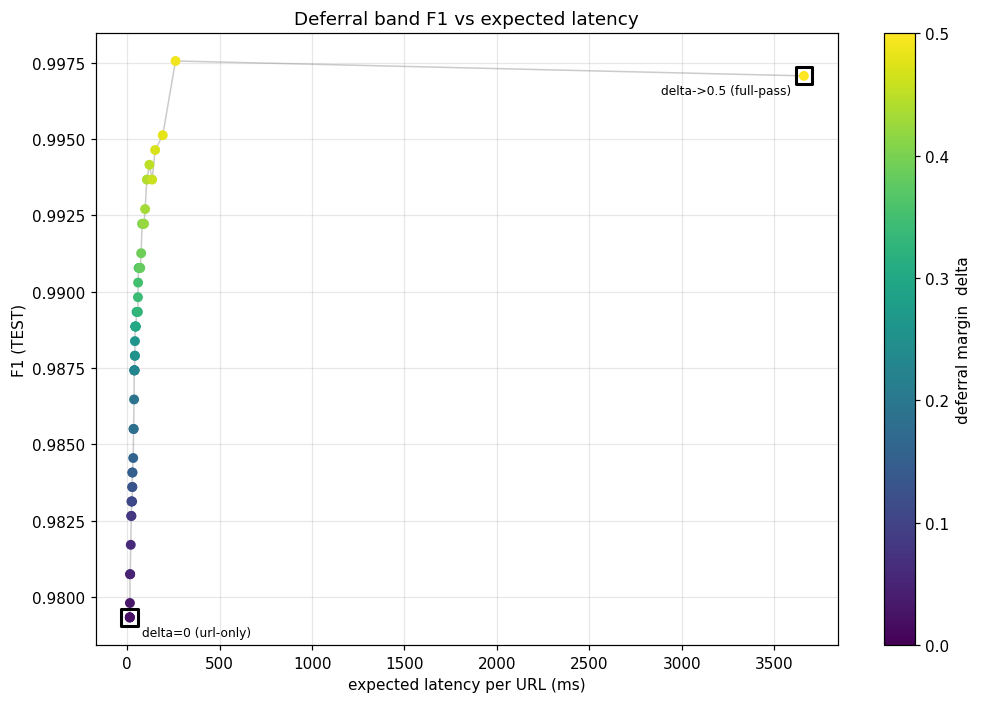

In [30]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))
# two-sided deferral band, colored by delta (faint connector traces the sweep order).
ax.plot(band_sweep["mean_latency_ms"], band_sweep["f1"], color="tab:gray", alpha=0.4, lw=1, zorder=3)
sc = ax.scatter(band_sweep["mean_latency_ms"], band_sweep["f1"], c=band_sweep["delta"],
                cmap="viridis", s=30, zorder=4, label="deferral band (delta sweep)")
plt.colorbar(sc, label="deferral margin  delta")
# endpoints of the band sweep.
for x, ylab, ha, dx in [(0, "delta=0 (url-only)", "left", 8), (-1, "delta->0.5 (full-pass)", "right", -8)]:
    ax.scatter([band_sweep["mean_latency_ms"].iloc[x]], [band_sweep["f1"].iloc[x]], s=120, marker="s",
               edgecolor="black", facecolor="none", lw=2, zorder=5)
    ax.annotate(ylab, (band_sweep["mean_latency_ms"].iloc[x], band_sweep["f1"].iloc[x]),
                fontsize=8, ha=ha, xytext=(dx, -12), textcoords="offset points")
ax.set_xlabel("expected latency per URL (ms)"); ax.set_ylabel("F1 (TEST)")
ax.set_title("Deferral band F1 vs expected latency")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Per-stage two-sided threshold evaluation

The two-sided analog of the per-stage threshold search: each stage gets its own **deferral margin**
`delta` (band `[0.5 - delta, 0.5 + delta]`) instead of a single early-exit bar. We grid-search the
per-stage margins `(url, content, domain)` over `[0, 0.5]` at **0.01 steps** (`51^3 = 132,651` combos).
Because the per-URL stage probabilities are already scored (the *Score per-URL stage probabilities*
section), each combo's verdict is pure array arithmetic on those probabilities -- **vectorized over
URLs**, no per-URL `_build_result` call -- so the fine grid runs in seconds. We then report the
F1-optimal config and the best config under each latency budget, mirroring the one-sided search.

In [31]:
# Per-stage deferral-margin grid -- VECTORIZED over URLs. The per-URL stage probabilities are fixed
# (already scored in test_probs); only the thresholds change per combo, so the cascade verdict is array
# arithmetic on those probabilities. A parity check vs band_pass guards exact equality.
DGRID3 = np.round(np.linspace(0.0, 0.5, 51), 4)   # 0.01 steps (use 11 for the coarse 0.05 grid)

# precompute per-stage P(phish) arrays ONCE (NaN where a URL lacks that stage), in production order.
_d = [dict(L) for L in test_probs_ord]
Pu = np.array([r.get("url",     np.nan) for r in _d])
Pc = np.array([r.get("content", np.nan) for r in _d])
Pd = np.array([r.get("domain",  np.nan) for r in _d])
has_c, has_d = ~np.isnan(Pc), ~np.isnan(Pd)
_agg = {"max": np.nanmax, "median": np.nanmedian}.get(DECISION.fallback_aggregation, np.nanmean)
fb_phish = _agg(np.vstack([Pu, Pc, Pd]), axis=0) >= FALLBACK_DECISION_BOUNDARY   # fallback verdict
Lu, Lc, Ld = (LAT_MS.get(s, 0.0) for s in ("url", "content", "domain"))
yb = (y_test == 1)

def band_combo_vec(du, dc, dd):
    '''Vectorized (preds bool, mean_latency_ms) for one per-stage delta combo -- matches band_pass.'''
    ex_u = (Pu <= 0.5 - du) | (Pu >= 0.5 + du)                    # url always present
    ex_c = has_c & ((Pc <= 0.5 - dc) | (Pc >= 0.5 + dc))
    ex_d = has_d & ((Pd <= 0.5 - dd) | (Pd >= 0.5 + dd))
    verdict = np.select([ex_u, ~ex_u & ex_c, ~ex_u & ~ex_c & ex_d],
                        [Pu >= 0.5, Pc >= 0.5, Pd >= 0.5], default=fb_phish)
    visit_c = ~ex_u & has_c                                       # content reached (and present)
    visit_d = ~ex_u & ~ex_c & has_d                              # domain reached (content didn't exit)
    lat = Lu + visit_c * Lc + visit_d * Ld
    return verdict.astype(bool), float(lat.mean())

def _prf1(v):
    tp = int((v & yb).sum()); fp = int((v & ~yb).sum()); fn = int((~v & yb).sum())
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    return p, r, (2 * p * r / (p + r) if (p + r) else 0.0)

# parity vs the per-URL band_pass on a few random combos (must be exactly equal).
def _ref_combo(du, dc, dd):
    band_of = sym_band({"url": du, "content": dc, "domain": dd, "_default": 0.0})
    pr, lt = [], 0.0
    for L in test_probs_ord:
        pred, _w, _n, lat = band_pass(L, band_of); pr.append(pred); lt += lat
    return np.array(pr), lt / len(test_probs_ord)

_rng = np.random.default_rng(0)
for _ in range(4):
    du, dc, dd = (float(_rng.choice(DGRID3)) for _ in range(3))
    vp, vl = band_combo_vec(du, dc, dd); rp, rl = _ref_combo(du, dc, dd)
    assert np.array_equal(vp.astype(int), rp) and abs(vl - rl) < 1e-6, (du, dc, dd)
print("parity: vectorized verdict == band_pass on sampled combos -- OK")

t0 = time.perf_counter()
rows = []
for du in DGRID3:
    for dc in DGRID3:
        for dd in DGRID3:
            v, mlat = band_combo_vec(float(du), float(dc), float(dd))
            p, r, f = _prf1(v)
            rows.append({"url": float(du), "content": float(dc), "domain": float(dd),
                         "precision": p, "recall": r, "f1": f, "mean_latency_ms": mlat})
bgrid3 = pd.DataFrame(rows)
print(f"evaluated {len(bgrid3)} per-stage (url x content x domain) deferral-margin combos on "
      f"{len(test_probs_ord)} TEST URLs in {time.perf_counter() - t0:.1f}s")

bg_best = bgrid3.loc[bgrid3["f1"].idxmax()]
print("\ntop-5 by F1 (unconstrained):")
print(bgrid3.sort_values("f1", ascending=False).head(5).round(4).to_string(index=False))
print(f"\nper-stage deferral-margin F1-optimal: url={bg_best.url} content={bg_best.content} "
      f"domain={bg_best.domain} -> F1={bg_best.f1:.4f} @ {bg_best.mean_latency_ms:.0f} ms")

parity: vectorized verdict == band_pass on sampled combos -- OK


evaluated 132651 per-stage (url x content x domain) deferral-margin combos on 2118 TEST URLs in 10.9s

top-5 by F1 (unconstrained):
 url  content  domain  precision  recall    f1  mean_latency_ms
 0.5     0.50    0.49     0.9961     1.0 0.998        3661.4639
 0.5     0.49    0.49     0.9961     1.0 0.998        3490.9260
 0.5     0.49    0.48     0.9961     1.0 0.998        3490.9260
 0.5     0.50    0.48     0.9961     1.0 0.998        3661.4639
 0.5     0.47    0.49     0.9961     1.0 0.998        3134.5988

per-stage deferral-margin F1-optimal: url=0.5 content=0.47 domain=0.48 -> F1=0.9980 @ 3135 ms


In [32]:
# Best per-stage deferral-margin config whose mean latency <= each budget (max F1 within budget).
BUDGETS = [50, 100, 250, 500, 1000, 2000, 4000]
bpicks = []
for b in BUDGETS:
    sub = bgrid3[bgrid3["mean_latency_ms"] <= b]
    if sub.empty:
        bpicks.append({"budget_ms": b, "url": np.nan, "content": np.nan,
                       "domain": np.nan, "f1": np.nan, "precision": np.nan, "recall": np.nan,
                       "mean_latency_ms": np.nan})
        continue
    r = sub.loc[sub["f1"].idxmax()]
    bpicks.append({"budget_ms": b, "url": r.url, "content": r.content,
                   "domain": r.domain, "f1": r.f1, "precision": r.precision, "recall": r.recall,
                   "mean_latency_ms": r.mean_latency_ms})
bpicks = pd.DataFrame(bpicks)
print("Best per-stage deferral-margin config under each latency budget (TEST):")
print(bpicks.round(4).to_string(index=False))

bgrid3.to_csv("eval_results/pipeline_band_per_stage_grid3.csv", index=False)
bpicks.to_csv("eval_results/pipeline_band_latency_constrained_picks.csv", index=False)
print("\nsaved -> eval_results/pipeline_band_per_stage_grid3.csv, pipeline_band_latency_constrained_picks.csv")

Best per-stage deferral-margin config under each latency budget (TEST):
 budget_ms  url  content  domain     f1  precision  recall  mean_latency_ms
        50 0.40     0.02    0.10 0.9908     0.9836   0.998          46.6767
       100 0.49     0.11    0.10 0.9956     0.9932   0.998          96.0259
       250 0.49     0.28    0.10 0.9980     0.9971   0.999         166.7367
       500 0.49     0.28    0.10 0.9980     0.9971   0.999         166.7367
      1000 0.49     0.28    0.10 0.9980     0.9971   0.999         166.7367
      2000 0.49     0.28    0.10 0.9980     0.9971   0.999         166.7367
      4000 0.50     0.47    0.48 0.9980     0.9961   1.000        3134.5988



saved -> eval_results/pipeline_band_per_stage_grid3.csv, pipeline_band_latency_constrained_picks.csv


## Export thesis figures (Results §5.4)

Rebuilds the end-to-end cascade figures from the in-memory sweep/band dataframes and writes them as
vector PDFs into `Master_Thesis/img/results/`, so re-running this notebook refreshes the thesis figures.


In [33]:
# === Export Results §5.4 figures (vector PDF) -> Master_Thesis/img/results ========================
# Single source of truth for the end-to-end cascade figures: rebuilt here from the in-memory
# sweep/band dataframes, so re-running this notebook refreshes the thesis figures directly (no
# separate generator script). Also persists the two in-memory sweeps so each figure has a CSV.
import os
FIGDIR = "Master_Thesis/img/results"
os.makedirs(FIGDIR, exist_ok=True)
def _save(fig, name):
    p = os.path.join(FIGDIR, name)
    fig.savefig(p, bbox_inches="tight"); plt.close(fig); print("saved ->", p)

MET = [("precision", "tab:blue"), ("recall", "tab:orange"), ("f1", "tab:green"), ("accuracy", "tab:red")]
EXIT_COLORS = ["tab:green", "gold", "tab:orange", "tab:red"]   # url, content, domain, fallback

sweep.to_csv("eval_results/pipeline_threshold_sweep.csv", index=False)
band_sweep.to_csv("eval_results/pipeline_band_delta_sweep.csv", index=False)

def _zoom(ax, df, cols):
    ys = df[cols].to_numpy(); ymin, ymax = float(np.nanmin(ys)), float(np.nanmax(ys))
    pad = 0.05 * (ymax - ymin) if not np.isclose(ymax - ymin, 0) else 0.05
    ax.set_ylim(max(0.0, ymin - pad), min(1.0, ymax + pad))

def _metric_panel(ax, df, x, xlabel):
    for m, c in MET:
        ax.plot(df[x], df[m], label=m, color=c)
    _zoom(ax, df, [m for m, _ in MET])
    ax.set_xlabel(xlabel); ax.set_ylabel("score"); ax.grid(alpha=0.3)
    ax.legend(loc="lower center", ncol=2, fontsize=8)

def _error_panel(ax, df, x, xlabel):
    ax.plot(df[x], df["fnr"], color="tab:purple", lw=2, label="FNR = missed phish / all phish")
    ax.plot(df[x], df["fpr"], color="tab:brown", lw=2, label="FPR = flagged benign / all benign")
    ax.set_xlabel(xlabel); ax.set_ylabel("error rate"); ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3); ax.legend(loc="upper right", fontsize=8)

def _comp_panels(axes, df, x, xlabel):
    for ax, kind, ylab in [(axes[0], "phish", "predicted-phish URLs"),
                           (axes[1], "benign", "predicted-benign URLs")]:
        ax.stackplot(df[x], *[df[f"{kind}_{p}"] for p in EXIT_POINTS],
                     labels=[f"exit @ {p}" for p in EXIT_POINTS], colors=EXIT_COLORS, alpha=0.85)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylab); ax.grid(alpha=0.25); ax.legend(loc="upper left", fontsize=8)
    axes[0].set_title("(a) predicted-phish exits"); axes[1].set_title("(b) predicted-benign exits")

def _pareto(df, x, val, label, name):
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.plot(df["mean_latency_ms"], df["f1"], color="tab:gray", alpha=0.4, lw=1, zorder=3)
    sc = ax.scatter(df["mean_latency_ms"], df["f1"], c=df[val], cmap="viridis", s=28, zorder=4)
    fig.colorbar(sc, ax=ax, label=label)
    ends = [(0, f"{x}=0 (url-only)", "left", 8), (-1, f"{x}->0.5 (full-pass)", "right", -8)]
    for i, lab, ha, dx in ends:
        ax.scatter([df["mean_latency_ms"].iloc[i]], [df["f1"].iloc[i]], s=120, marker="s",
                   edgecolor="black", facecolor="none", lw=2, zorder=5)
        ax.annotate(lab, (df["mean_latency_ms"].iloc[i], df["f1"].iloc[i]), fontsize=8, ha=ha,
                    xytext=(dx, -12), textcoords="offset points")
    ax.set_xlabel("expected latency per URL (ms)"); ax.set_ylabel("F1 (test)"); ax.grid(alpha=0.3)
    fig.tight_layout(); _save(fig, name)

# (1) fusion vs single -- full-pass aggregations (warm) vs single-stage classifiers (cool)
COL = {"full-pass": "tab:red", "single-stage": "tab:green"}
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for _, r in fullpass.iterrows():
    ax.scatter(r["mean_latency_ms"], r["f1"], s=95, color=COL[r["kind"]], zorder=3)
    ax.annotate(r["system"], (r["mean_latency_ms"], r["f1"]), fontsize=7.5, xytext=(5, 3), textcoords="offset points")
ax.set_xscale("log")
handles = [plt.Line2D([], [], marker="o", ls="", color=COL["full-pass"], label="full-pass fusion"),
           plt.Line2D([], [], marker="o", ls="", color=COL["single-stage"], label="single stage")]
ax.legend(handles=handles, loc="lower right", fontsize=9)
ax.set_xlabel("expected latency per URL (ms, log scale)"); ax.set_ylabel("F1 (test)")
ax.grid(alpha=0.3, which="both"); fig.tight_layout(); _save(fig, "fusion_vs_single.pdf")

# (2) one-sided sweep: metrics | error rates vs threshold
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
_metric_panel(axes[0], sweep, "threshold", "early-exit threshold")
axes[0].set_title("(a) metrics vs threshold")
_error_panel(axes[1], sweep, "threshold", "early-exit threshold")
axes[1].set_title("(b) error rates vs threshold")
fig.tight_layout(); _save(fig, "onesided_sweep.pdf")

# (3) one-sided exit composition: phish | benign vs threshold
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
_comp_panels(axes, costsweep, "threshold", "early-exit threshold")
fig.tight_layout(); _save(fig, "composition_onesided.pdf")

# (4) one-sided Pareto
_pareto(tradeoff, "threshold", "threshold", "early-exit threshold", "pareto_onesided.pdf")

# (5) two-sided band sweep: metrics | error rates vs delta
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
_metric_panel(axes[0], band_sweep, "delta", "deferral margin")
axes[0].set_title("(a) metrics vs margin")
_error_panel(axes[1], band_sweep, "delta", "deferral margin")
axes[1].set_title("(b) error rates vs margin")
fig.tight_layout(); _save(fig, "band_sweep.pdf")

# (6) two-sided exit composition: phish | benign vs delta
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
_comp_panels(axes, band_cost, "delta", "deferral margin")
fig.tight_layout(); _save(fig, "composition_band.pdf")

# (7) two-sided Pareto
_pareto(band_sweep, "delta", "delta", "deferral margin", "pareto_band.pdf")

print("\nAll Results 5.4 figures exported to", FIGDIR)


saved -> Master_Thesis/img/results/fusion_vs_single.pdf


saved -> Master_Thesis/img/results/onesided_sweep.pdf


saved -> Master_Thesis/img/results/composition_onesided.pdf
saved -> Master_Thesis/img/results/pareto_onesided.pdf


saved -> Master_Thesis/img/results/band_sweep.pdf


saved -> Master_Thesis/img/results/composition_band.pdf
saved -> Master_Thesis/img/results/pareto_band.pdf

All Results 5.4 figures exported to Master_Thesis/img/results
